# Análisis Global de Precios de Combustibles 2020–2026
## Evolución, Volatilidad y Factores Explicativos en 84 Países

**Curso:** IMT-3860 — Introducción a Data Science (Magíster en Ingeniería Industrial, PUC Chile)
**Profesor:** Alejandro Cataldo
**Equipo:** Armando Arredondo · Bastián Hernández · Francisco Nahamías · Eduardo Albornoz

---

## Estructura del notebook

| Sección | Contenido |
|---|---|
| **0** | Setup: rutas, imports, verificación |
| **1** | Ingesta de las 5 fuentes y armonización temporal |
| **2** | Validación de calidad (QA) |
| **3** | Limpieza y detección de anomalías |
| **4** | EDA univariado (distribuciones, log-transformación) |
| **5** | EDA bivariado y temporal (correlaciones, series) |
| **6** | EDA por grupos (región, ingreso, subsidio) |
| **7** | Ingeniería de variables (55 features derivadas) |
| **8** | PI-1: Diferencias de medias (Welch + Tukey) |
| **9** | PI-2: Volatilidad (Levene) |
| **10** | PI-3: Pass-through del Brent (Panel FE + Driscoll-Kraay + Mork) |
| **11** | PI-4: Modelos predictivos ML |
| **12** | PI-5: Interpretabilidad SHAP |
| **13** | Discusión y conclusiones |

## Convención del notebook

Para facilitar la lectura, cada sección comienza con una caja como esta:

> **DataFrame en uso: `nombre`**
> **Dimensiones**: X filas × Y columnas
> **Descripción**: qué representa cada fila y qué información agrega esta etapa.

Las funciones se definen **justo antes de usarse** en lugar de concentrarse al principio,
para que el flujo de lectura sea natural y cada bloque sea autocontenido.


## 0. Setup

### 0.1 Configuración de la ruta a los datos

Ajusta `DATA_DIR` si tus archivos están en otra carpeta.


In [80]:
import os
from pathlib import Path

# RUTA A LOS DATOS
# Busca la carpeta Datasets en varias rutas relativas posibles
# para funcionar sin importar desde donde se lance el kernel.
_candidates = [
    Path("../../Datasets"),         # desde Project-Phase2/Notebooks/
    Path("../Datasets"),            # desde Project-Phase2/
    Path("Datasets"),               # desde la raiz del repo
    Path("../../../Datasets"),       # un nivel extra por si acaso
]
DATA_DIR = None
for p in _candidates:
    if p.is_dir():
        DATA_DIR = p.resolve()
        break
if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontro la carpeta Datasets. "
        "Asegurate de que el repo este clonado correctamente."
    )

# Archivos esperados en la carpeta
FILES = {
    "main":  "global_fuel_prices_2020_2026.csv",
    "brent": "Brend Europa Fred.csv",
    "ovx":   "CBOE Crude Oil ETF Volatility.csv",
    "dxy":   "Nominal Broand US Dollar.csv",
    "gpr":   "data_gpr_export(Sheet1).csv",
}

print(f"Ruta configurada: {DATA_DIR}")
for tag, fname in FILES.items():
    fpath = DATA_DIR / fname
    status = "OK" if fpath.exists() else "FALTA"
    print(f"  [{status}] {fname}")


Ruta configurada: D:\IntroDataScienceProyecto\Datasets
  [OK] global_fuel_prices_2020_2026.csv
  [OK] Brend Europa Fred.csv
  [OK] CBOE Crude Oil ETF Volatility.csv
  [OK] Nominal Broand US Dollar.csv
  [OK] data_gpr_export(Sheet1).csv


### 0.2 Instalación automática de librerías faltantes

Si alguna librería no está instalada en tu entorno, la siguiente celda la instalará.


In [81]:
# Detectar e instalar librerias faltantes (silenciosamente)
import importlib, subprocess, sys

required = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy',
            'statsmodels', 'linearmodels', 'scikit-learn',
            'xgboost', 'lightgbm', 'shap']

missing = []
for pkg in required:
    mod_name = pkg.replace('-', '_') if pkg != 'scikit-learn' else 'sklearn'
    try:
        importlib.import_module(mod_name)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f'Instalando: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print('Instalacion completa. REINICIA EL KERNEL si algo falla luego.')
else:
    print('Todas las librerias requeridas estan instaladas.')


Todas las librerias requeridas estan instaladas.


### 0.3 Imports y configuración de visualización

Cargamos el stack científico estándar y configuramos los estilos de matplotlib/seaborn
que usaremos en todo el análisis.


In [82]:
import warnings
warnings.filterwarnings('ignore')

# Stack cientifico estandar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # para formato de fechas en graficos
import seaborn as sns
from scipy import stats

# Config de pandas para impresion clara
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Estilo visual consistente
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 200,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 10,
})
sns.set_palette('colorblind')

print('Librerias cargadas y estilos aplicados.')


Librerias cargadas y estilos aplicados.


## 1. Ingesta y armonización temporal

El proyecto integra **5 fuentes de datos heterogéneas**, con distinta frecuencia:

| Fuente | Qué aporta | Frecuencia | Formato |
|---|---|---|---|
| Kaggle | precios retail (petrol/diesel/lpg), Brent, impuestos | semanal | CSV estándar |
| FRED DCOILBRENTEU | Brent (verificación cruzada) | diaria | CSV con `observation_date` |
| FRED OVXCLS | OVX (volatilidad implícita del crudo) | diaria | CSV estándar |
| FRED DTWEXBGS | Dollar Index (DXY) | diaria | CSV estándar |
| Caldara-Iacoviello | GPR Index (riesgo geopolítico) | mensual | CSV con `;` y coma decimal |

> **Decisión clave**: usamos la **grilla semanal del Kaggle** como referencia. Las series
> diarias (FRED) se agregan como **media semanal**; la mensual (GPR) se propaga por mes
> (forward-fill).

### 1.1 Carga del dataset principal

> **DataFrame en uso: `df_main`**  
> **Dimensiones**: 27,468 filas × 10 columnas  
> **Descripción**: Panel principal: **1 fila = 1 país × 1 semana**. Incluye precios retail, Brent referencial, impuestos y clasificación por región/ingreso/subsidio.


In [83]:
# --- Funcion de carga del dataset principal -------------------------------
def load_main(data_dir: Path) -> pd.DataFrame:
    '''
    Carga el CSV de Kaggle y convierte las columnas categoricas a tipo categorico ordenado.
    Esto es importante porque 'income_level' y 'subsidy_level' tienen un orden natural
    (Low < Middle < High) que queremos preservar para los analisis.
    '''
    path = data_dir / FILES['main']
    df = pd.read_csv(path, parse_dates=['date'])
    # Tipos categoricos ORDENADOS (el orden importa para plots y tests)
    df['country'] = df['country'].astype('category')
    df['region'] = df['region'].astype('category')
    df['income_level'] = pd.Categorical(df['income_level'],
                                         categories=['Low', 'Middle', 'High'],
                                         ordered=True)
    df['subsidy_level'] = pd.Categorical(df['subsidy_level'],
                                          categories=['Low', 'Medium', 'High', 'Very High'],
                                          ordered=True)
    # Orden canonico: por pais y luego por fecha
    return df.sort_values(['country', 'date']).reset_index(drop=True)


# Cargamos el dataset principal
df_main = load_main(DATA_DIR)
print(f'df_main: {df_main.shape[0]:,} filas x {df_main.shape[1]} columnas')
print(f'Rango temporal: {df_main["date"].min().date()} a {df_main["date"].max().date()}')
print(f'Paises: {df_main["country"].nunique()}')
df_main.head()


df_main: 27,468 filas x 10 columnas
Rango temporal: 2020-01-06 a 2026-04-06
Paises: 84


,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,Algeria,Africa,Middle,Very High,0.0630,0.0700,0.0480,65.7500,5.6000
1,2020-01-13,Algeria,Africa,Middle,Very High,0.0930,0.0800,0.0920,65.5400,16.7000
2,2020-01-20,Algeria,Africa,Middle,Very High,0.1040,0.0450,0.0690,66.5100,27.3000
3,2020-01-27,Algeria,Africa,Middle,Very High,0.0940,0.0810,0.0810,68.7900,16.8000
4,2020-02-03,Algeria,Africa,Middle,Very High,0.0810,0.0540,0.0620,68.4400,25.5000


### 1.2 Inspección de tipos y categorías

Antes de avanzar verificamos qué tipos de datos tenemos y cuántos niveles únicos hay en
cada variable categórica.


In [84]:
# Tipos de datos
print('Tipos de datos:')
print(df_main.dtypes.to_string())
print(f'\nMemoria usada: {df_main.memory_usage(deep=True).sum() / 1024**2:.2f} MB')


Tipos de datos:
date                datetime64[us]
country                   category
region                    category
income_level              category
subsidy_level             category
petrol_usd_liter           float64
diesel_usd_liter           float64
lpg_usd_liter              float64
brent_crude_usd            float64
tax_percentage             float64

Memoria usada: 1.37 MB


In [85]:
# Niveles unicos por categoria
print('Niveles unicos por variable categorica:')
for col in ['country', 'region', 'income_level', 'subsidy_level']:
    vals = df_main[col].cat.categories.tolist()
    print(f'  {col} ({len(vals)} niveles): {vals[:10]}{"..." if len(vals)>10 else ""}')


Niveles unicos por variable categorica:
  country (84 niveles): ['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Bangladesh', 'Belgium', 'Botswana', 'Brazil', 'Cameroon']...
  region (7 niveles): ['Africa', 'Asia', 'Europe', 'Middle East', 'North America', 'Oceania', 'South America']
  income_level (3 niveles): ['Low', 'Middle', 'High']
  subsidy_level (4 niveles): ['Low', 'Medium', 'High', 'Very High']


**Observación clave**: el documento original del proyecto sugería `subsidy_level` con
sólo 2 niveles, pero el dataset real trae **4 niveles** (`Low`, `Medium`, `High`, `Very High`).
Los 4 niveles aportan más granularidad al análisis y los mantendremos.

### 1.3 Carga de las series FRED (diarias)

> **DataFrame en uso: `df_brent, df_ovx, df_dxy`**  
> **Dimensiones**: variable (≈1,500) filas × 2 c/u columnas  
> **Descripción**: Series diarias del FRED. Cada fila es una observación diaria; la armonizamos a frecuencia semanal promediando los días de cada semana.


In [86]:
# --- Funcion de carga para cualquier serie FRED ---------------------------
def load_fred(data_dir: Path, file_key: str, value_col: str, new_name: str) -> pd.DataFrame:
    '''
    Carga una serie diaria del FRED. Las descargas de FRED siempre tienen:
    - columna 'observation_date' con fechas
    - una columna con el valor (cuyo nombre depende de la serie)

    Renombramos para trabajar con nombres homogeneos.
    '''
    path = data_dir / FILES[file_key]
    df = pd.read_csv(path, parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', value_col: new_name})
    df[new_name] = pd.to_numeric(df[new_name], errors='coerce')
    return df.dropna().sort_values('date').reset_index(drop=True)


# Cargamos las tres series FRED
df_brent = load_fred(DATA_DIR, 'brent', 'DCOILBRENTEU', 'brent_fred')
df_ovx   = load_fred(DATA_DIR, 'ovx',   'OVXCLS',       'ovx')
df_dxy   = load_fred(DATA_DIR, 'dxy',   'DTWEXBGS',     'dxy')

print(f'df_brent: {df_brent.shape[0]} observaciones diarias')
print(f'df_ovx:   {df_ovx.shape[0]} observaciones diarias')
print(f'df_dxy:   {df_dxy.shape[0]} observaciones diarias')
df_brent.head(3)


df_brent: 1840 observaciones diarias
df_ovx:   1830 observaciones diarias
df_dxy:   1816 observaciones diarias


,date,brent_fred
0,2019-01-02,54.0600
1,2019-01-03,53.2300
2,2019-01-04,55.6400


### 1.4 Carga del índice GPR (mensual)

> **DataFrame en uso: `df_gpr`**  
> **Dimensiones**: ≈75 filas × 4 columnas  
> **Descripción**: Índice mensual de Riesgo Geopolítico (Caldara & Iacoviello, 2022). `GPR` es el índice global; `GPRA` es componente 'actos'; `GPRT` es 'amenazas'. Se propagará dentro del mes al merge.


In [87]:
def load_gpr(data_dir: Path) -> pd.DataFrame:
    '''
    Carga el GPR Index (Caldara-Iacoviello). Este CSV es peculiar:
    - separador `;` (no `,`)
    - coma decimal (no punto)
    - fechas en formato DD/MM/YYYY
    '''
    path = data_dir / FILES['gpr']
    raw = pd.read_csv(path, sep=';', encoding='utf-8-sig')
    raw['month'] = pd.to_datetime(raw['month'], format='%d/%m/%Y', errors='coerce')
    # Convertimos las columnas numericas (vienen con coma decimal)
    out = raw[['month', 'GPR', 'GPRA', 'GPRT']].copy()
    for c in ['GPR', 'GPRA', 'GPRT']:
        out[c] = pd.to_numeric(out[c].astype(str).str.replace(',', '.'), errors='coerce')
    out = out.dropna(subset=['month']).sort_values('month').reset_index(drop=True)
    return out.rename(columns={'month': 'date', 'GPR': 'gpr',
                                'GPRA': 'gpr_acts', 'GPRT': 'gpr_threats'})


df_gpr = load_gpr(DATA_DIR)
print(f'df_gpr: {df_gpr.shape[0]} observaciones mensuales')
df_gpr.head(3)


df_gpr: 1515 observaciones mensuales


,date,gpr,gpr_acts,gpr_threats
0,1900-01-01,NaN,NaN,NaN
1,1900-02-01,NaN,NaN,NaN
2,1900-03-01,NaN,NaN,NaN


### 1.5 Variables adicionales desde FRED (descarga automática)

Siguiendo las recomendaciones de la literatura sobre pricing de combustibles retail (EIA 2016, 
MDPI Energies 2024, CME Crack Spread Guide), incorporamos series adicionales que no estaban en 
el análisis original pero que la evidencia empírica señala como determinantes causales del precio 
retail. Los archivos deben estar en la misma carpeta `DATA_DIR` con los nombres indicados.

| Variable | Archivo | Justificación literatura |
|---|---|---|
| RBOB NY Harbor (diaria) | `DGASNYH.csv` | Precio mayorista gasolina — permite calcular **crack spread** (RBOB−Brent). EIA: "determinante clave del markup refinador". |
| WTI (diaria) | `DCOILWTICO.csv` | Benchmark crudo americano. **Brent-WTI spread** captura fricciones logísticas globales. |
| Henry Hub natgas (diaria) | `DHHNGSP.csv` | Combustible sustituto; afecta decisiones de cracking. |
| Inventarios crudo EE.UU. (semanal) | `WCESTUS1w.xls` | EIA: "inventarios son factor fundamental del pricing". |
| Inventarios gasolina EE.UU. (semanal) | `Stock_of_total_gasoline.xls` | Cuando inventarios altos, crack spread se estrecha. |
| Utilización refinerías (semanal) | `Utilizacion_of_refinery.xls` | Captura shocks de oferta (cierres, mantenimiento). |

> **DataFrame en uso: `df_rbob, df_wti, df_ng (diarias) + df_invcrude, df_invgas, df_refutil (semanales)`**  
> **Dimensiones**: variable filas × 2 c/u columnas  
> **Descripción**: Series adicionales de FRED/EIA en formato local. Las diarias (`DGASNYH`, `DCOILWTICO`, `DHHNGSP`) se agregan a frecuencia semanal; las semanales de EIA ya vienen en la frecuencia correcta.


In [88]:
!pip install xlrd openpyxl


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
# Archivos de las variables adicionales (deben estar en DATA_DIR)
FRED_FILES_EXTRA = {
    # (archivo, tipo, columna_valor, alias_final)
    'rbob_ny':        ('DGASNYH.csv',                  'csv_fred',  'DGASNYH'),
    'wti':            ('DCOILWTICO.csv',               'csv_fred',  'DCOILWTICO'),
    'henryhub':       ('DHHNGSP.csv',                  'csv_fred',  'DHHNGSP'),
    'inv_crude':      ('WCESTUS1w.xls',                'xls_eia',   None),
    'inv_gasoline':   ('Stock_of_total_gasoline.xls',  'xls_eia',   None),
    'refinery_util':  ('Utilizacion_of_refinery.xls',  'xls_eia',   None),
}


def load_csv_fred_local(path: Path, value_col: str, alias: str) -> pd.DataFrame:
    '''Lee un CSV de FRED descargado localmente (formato: observation_date, SERIES_ID).'''
    df = pd.read_csv(path, parse_dates=['observation_date'])
    df = df.rename(columns={'observation_date': 'date', value_col: alias})
    df[alias] = pd.to_numeric(df[alias], errors='coerce')
    return df.dropna(subset=[alias]).sort_values('date').reset_index(drop=True)


def load_xls_eia_local(path: Path, alias: str) -> pd.DataFrame:
    '''
    Lee un XLS de EIA. Estos archivos tienen 2 hojas:
    - "Contents": hoja con descripcion (se ignora).
    - "Data 1": hoja con los datos. Las primeras 2 filas son header/descripcion;
       la columna A es fecha y la B es el valor.

    Saltamos con skiprows=2 y renombramos la columna de valor al alias.
    '''
    df = pd.read_excel(path, sheet_name='Data 1', skiprows=2, names=['date', alias])
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df[alias] = pd.to_numeric(df[alias], errors='coerce')
    return df.dropna(subset=['date', alias]).sort_values('date').reset_index(drop=True)


# Cargamos cada serie con el tipo correspondiente
fred_extra_data = {}
for alias, (fname, tipo, value_col) in FRED_FILES_EXTRA.items():
    full_path = DATA_DIR / fname
    if not full_path.exists():
        print(f'  [FALTA] {fname}: archivo no existe en {DATA_DIR}. Variable {alias} = NaN.')
        fred_extra_data[alias] = None
        continue
    try:
        if tipo == 'csv_fred':
            df_tmp = load_csv_fred_local(full_path, value_col, alias)
        elif tipo == 'xls_eia':
            df_tmp = load_xls_eia_local(full_path, alias)
        else:
            raise ValueError(f'tipo desconocido: {tipo}')
        fred_extra_data[alias] = df_tmp
        print(f'  [OK] {fname} -> {alias}: {len(df_tmp)} obs, '
              f'rango {df_tmp["date"].min().date()} a {df_tmp["date"].max().date()}')
    except Exception as e:
        print(f'  [ERROR] {fname}: {e}. Variable {alias} = NaN.')
        fred_extra_data[alias] = None


  [OK] DGASNYH.csv -> rbob_ny: 10014 obs, rango 1986-06-02 a 2026-04-13
  [OK] DCOILWTICO.csv -> wti: 10138 obs, rango 1986-01-02 a 2026-04-13
  [OK] DHHNGSP.csv -> henryhub: 7348 obs, rango 1997-01-07 a 2026-04-13
  [OK] WCESTUS1w.xls -> inv_crude: 2272 obs, rango 1982-08-20 a 2026-04-10
  [OK] Stock_of_total_gasoline.xls -> inv_gasoline: 1893 obs, rango 1990-01-05 a 2026-04-10
  [OK] Utilizacion_of_refinery.xls -> refinery_util: 1850 obs, rango 1990-11-02 a 2026-04-10


### 1.6 Armonización: merge de todas las fuentes a frecuencia semanal


Ahora combinamos las 5 fuentes en un único panel enriquecido.

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × 17 columnas  
> **Descripción**: Panel enriquecido: misma granularidad que `df_main` (país × semana), pero con columnas adicionales de Brent-FRED, OVX, DXY y GPR alineadas.


In [90]:
def to_weekly_mean(df_daily: pd.DataFrame, value_cols: list) -> pd.DataFrame:
    '''
    Agrega una serie diaria a frecuencia semanal tomando la media de cada semana.
    Usamos periodos semanales que empiezan el lunes (coincide con el panel principal)
    y tomamos la fecha de inicio de cada semana como etiqueta.
    '''
    out = df_daily.copy()
    # 'W-MON' genera periodos lunes-domingo; start_time da el lunes de esa semana
    out['week'] = out['date'].dt.to_period('W-MON').dt.start_time
    out = (out.groupby('week')[value_cols].mean()
              .reset_index()
              .rename(columns={'week': 'date'}))
    return out


def align_to_panel(df_weekly: pd.DataFrame, panel_dates: pd.DatetimeIndex,
                   value_cols: list) -> pd.DataFrame:
    '''
    Alinea una serie semanal a las fechas exactas del panel principal.
    Estrategia robusta: unimos las fechas de la serie con las del panel y luego
    interpolamos. Asi no dependemos de que las fechas coincidan exactamente.
    '''
    serie = df_weekly.set_index('date').sort_index()
    # Indice combinado: union de las fechas propias de la serie y las del panel
    all_dates = serie.index.union(panel_dates)
    # Interpolar por tiempo sobre el indice combinado, luego quedarnos con las del panel
    result = (serie.reindex(all_dates)
                   .interpolate(method='time', limit=14)
                   .ffill()
                   .bfill()
                   .loc[panel_dates]
                   .reset_index()
                   .rename(columns={'index': 'date'}))
    return result


def expand_monthly(df_monthly: pd.DataFrame, panel_dates: pd.DatetimeIndex,
                   value_cols: list) -> pd.DataFrame:
    '''Propaga valores mensuales a la grilla semanal (forward fill dentro del mes).'''
    daily_grid = pd.date_range(panel_dates.min(), panel_dates.max(), freq='D')
    expanded = (df_monthly.set_index('date')[value_cols]
                          .reindex(daily_grid, method='ffill')
                          .bfill()
                          .reset_index()
                          .rename(columns={'index': 'date'}))
    # Ahora nos quedamos solo con las fechas del panel
    return expanded[expanded['date'].isin(panel_dates)].reset_index(drop=True)


# Fechas-semana del panel principal
panel_dates = pd.DatetimeIndex(sorted(df_main['date'].unique()))

# Paso 1: series diarias FRED -> semanal -> alineadas al panel
brent_w = align_to_panel(to_weekly_mean(df_brent, ['brent_fred']), panel_dates, ['brent_fred'])
ovx_w   = align_to_panel(to_weekly_mean(df_ovx,   ['ovx']),        panel_dates, ['ovx'])
dxy_w   = align_to_panel(to_weekly_mean(df_dxy,   ['dxy']),        panel_dates, ['dxy'])

# Paso 2: GPR mensual -> semanal
gpr_w = expand_monthly(df_gpr, panel_dates, ['gpr', 'gpr_acts', 'gpr_threats'])

# --- Utilidad: merge seguro con validacion ---
def safe_merge(left, right, on='date', how='left', name=''):
    '''Merge con validacion: verifica unicidad de clave en right y preservacion de filas.'''
    # Verificar que right no tiene duplicados en la clave
    dups = right[right.duplicated(subset=[on], keep=False)]
    if len(dups) > 0:
        print(f'  ⚠ {name}: {len(dups)} filas duplicadas en clave "{on}", agregando por media')
        right = right.groupby(on).mean(numeric_only=True).reset_index()
    n_before = len(left)
    result = left.merge(right, on=on, how=how, validate='many_to_one')
    n_after = len(result)
    if n_after != n_before:
        raise ValueError(f'{name}: merge cambio filas de {n_before:,} a {n_after:,}')
    print(f'  ✓ {name}: {n_after:,} filas, {result.shape[1]} cols')
    return result

# Paso 3: merge base (con validacion)
print('Merging fuentes externas al panel...')
df = safe_merge(df_main, brent_w, on='date', name='Brent FRED')
df = safe_merge(df, ovx_w, on='date', name='OVX')
df = safe_merge(df, dxy_w, on='date', name='DXY')
df = safe_merge(df, gpr_w, on='date', name='GPR')

# Paso 4 (NUEVO V4): agregar las series FRED extra
# Las diarias (RBOB, WTI, HenryHub) se convierten a semanal;
# las semanales (inventarios, refinery util) se alinean al panel directamente
for alias, df_src in fred_extra_data.items():
    if df_src is None:
        df[alias] = np.nan
        continue
    # Si tiene >200 obs y rango de fechas diario, la tratamos como diaria
    if len(df_src) > 200:
        # Frecuencia media de la serie (dias entre obs)
        freq_days = (df_src['date'].diff().median()).days if len(df_src) > 1 else 1
        if freq_days <= 2:
            src_weekly = to_weekly_mean(df_src, [alias])
        else:
            src_weekly = df_src.copy()
    else:
        src_weekly = df_src.copy()
    # Alinear al panel (interpola si hace falta)
    src_aligned = align_to_panel(src_weekly, panel_dates, [alias])
    df = safe_merge(df, src_aligned, on='date', name=alias)

print(f'Panel enriquecido: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Variables FRED extra incorporadas: {list(fred_extra_data.keys())}')
df.head(3)


Merging fuentes externas al panel...
  ✓ Brent FRED: 27,468 filas, 11 cols
  ✓ OVX: 27,468 filas, 12 cols
  ✓ DXY: 27,468 filas, 13 cols
  ✓ GPR: 27,468 filas, 16 cols
  ✓ rbob_ny: 27,468 filas, 17 cols
  ✓ wti: 27,468 filas, 18 cols
  ✓ henryhub: 27,468 filas, 19 cols
  ✓ inv_crude: 27,468 filas, 20 cols
  ✓ inv_gasoline: 27,468 filas, 21 cols
  ✓ refinery_util: 27,468 filas, 22 cols
Panel enriquecido: 27,468 filas x 22 columnas
Variables FRED extra incorporadas: ['rbob_ny', 'wti', 'henryhub', 'inv_crude', 'inv_gasoline', 'refinery_util']


,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,brent_fred,ovx,dxy,gpr,gpr_acts,gpr_threats,rbob_ny,wti,henryhub,inv_crude,inv_gasoline,refinery_util
0,2020-01-06,Algeria,Africa,Middle,Very High,0.0630,0.0700,0.0480,65.7500,5.6000,66.9694,32.1461,115.0907,138.4200,81.6500,190.8400,1.7174,60.1521,2.0776,429967.5714,254471.0000,92.6571
1,2020-01-13,Algeria,Africa,Middle,Very High,0.0930,0.0800,0.0920,65.5400,16.7000,64.5669,31.5050,115.0268,138.4200,81.6500,190.8400,1.6949,58.5321,2.0733,428337.4286,259034.8571,91.4714
2,2020-01-20,Algeria,Africa,Middle,Very High,0.1040,0.0450,0.0690,66.5100,27.3000,61.4431,32.3491,115.4002,138.4200,81.6500,190.8400,1.6088,55.9368,1.9692,429626.5714,260547.5714,89.0857


In [91]:
# --- Validacion de la estructura del panel post-merge ---
def validate_panel(df, df_ref, label=''):
    '''Valida integridad del panel despues del merge.'''
    print(f'\n{"="*60}')
    print(f'VALIDACION DEL PANEL {label}')
    print(f'{"="*60}')

    # 1. Filas preservadas
    assert len(df) == len(df_ref), (
        f'Filas cambiaron: {len(df_ref):,} -> {len(df):,}')
    print(f'✓ Filas preservadas: {len(df):,}')

    # 2. Sin duplicados (country, date)
    dups = df.duplicated(subset=['country', 'date'])
    assert dups.sum() == 0, f'{dups.sum()} duplicados en (country, date)'
    print(f'✓ Sin duplicados (country, date)')

    # 3. Mismos paises
    n_countries = df['country'].nunique()
    n_ref = df_ref['country'].nunique()
    assert n_countries == n_ref, f'Paises: {n_ref} -> {n_countries}'
    print(f'✓ Paises: {n_countries}')

    # 4. Cobertura temporal
    dates = sorted(df['date'].unique())
    print(f'✓ Rango: {dates[0].date()} a {dates[-1].date()} ({len(dates)} semanas)')

    # 5. Balance
    obs_per_country = df.groupby('country', observed=True).size()
    if obs_per_country.nunique() == 1:
        print(f'✓ Panel balanceado: {obs_per_country.iloc[0]} obs/pais')
    else:
        print(f'⚠ Panel desbalanceado: min={obs_per_country.min()}, max={obs_per_country.max()}')

    # 6. NaN en exogenas
    exog_cols = [c for c in df.columns if c not in df_ref.columns]
    if exog_cols:
        miss = df[exog_cols].isna().sum()
        miss_pct = (miss / len(df) * 100).round(1)
        for col in exog_cols:
            status = '✓' if miss[col] == 0 else '⚠'
            print(f'  {status} {col}: {miss[col]:,} NaN ({miss_pct[col]}%)')

    print(f'{"="*60}\n')

validate_panel(df, df_main, 'POST-MERGE')


VALIDACION DEL PANEL POST-MERGE
✓ Filas preservadas: 27,468
✓ Sin duplicados (country, date)
✓ Paises: 84
✓ Rango: 2020-01-06 a 2026-04-06 (327 semanas)
✓ Panel balanceado: 327 obs/pais
  ✓ brent_fred: 0 NaN (0.0%)
  ✓ ovx: 0 NaN (0.0%)
  ✓ dxy: 0 NaN (0.0%)
  ✓ gpr: 0 NaN (0.0%)
  ✓ gpr_acts: 0 NaN (0.0%)
  ✓ gpr_threats: 0 NaN (0.0%)
  ✓ rbob_ny: 0 NaN (0.0%)
  ✓ wti: 0 NaN (0.0%)
  ✓ henryhub: 0 NaN (0.0%)
  ✓ inv_crude: 0 NaN (0.0%)
  ✓ inv_gasoline: 0 NaN (0.0%)
  ✓ refinery_util: 0 NaN (0.0%)



## 2. Validación de calidad de datos (QA)

Antes de cualquier análisis verificamos la **integridad del dataset**. La función
`quality_report` revisa los problemas típicos en datos de panel.

> **DataFrame en uso: `df_main, df`**  
> **Dimensiones**: 27,468 / 27,468 filas × 10 / 17 columnas  
> **Descripción**: Revisamos `df_main` para chequeos del dataset original y `df` para cobertura post-merge de las exógenas.


In [92]:
def quality_report(df: pd.DataFrame) -> None:
    '''
    Imprime un reporte de calidad con chequeos tipicos:
    - Dimensiones y rango de fechas
    - Missing por columna
    - Duplicados (pais-fecha)
    - Balance del panel (igual cantidad de obs por pais?)
    - Rangos validos de precios e impuestos
    '''
    print('=' * 60)
    print('REPORTE DE CALIDAD DEL DATASET')
    print('=' * 60)

    # Dimensiones
    print(f'\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
    print(f'Rango: {df["date"].min().date()} a {df["date"].max().date()}')
    print(f'Semanas unicas: {df["date"].nunique()}')
    print(f'Paises unicos: {df["country"].nunique()}')

    # Missing
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss) == 0:
        print('\nSin valores faltantes.')
    else:
        print(f'\nValores faltantes: {dict(miss)}')

    # Duplicados pais-fecha
    dups = df.duplicated(subset=['country', 'date']).sum()
    print(f'Duplicados (pais, fecha): {dups}')

    # Balance del panel
    obs_pais = df.groupby('country', observed=True).size()
    balanced = obs_pais.nunique() == 1
    print(f'Panel balanceado: {balanced} (min={obs_pais.min()}, max={obs_pais.max()})')

    # Rangos de precios
    price_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']
    available = [c for c in price_cols if c in df.columns]
    if available:
        print('\nRangos de precios (USD/L):')
        for c in available:
            n_neg = (df[c] <= 0).sum()
            n_high = (df[c] > 10).sum()
            print(f'  {c}: min={df[c].min():.3f}, max={df[c].max():.3f}, '
                  f'<=0: {n_neg}, >10: {n_high}')

    # Impuestos
    if 'tax_percentage' in df.columns:
        tax_out = ((df['tax_percentage'] < 0) | (df['tax_percentage'] > 100)).sum()
        print(f'\nImpuestos fuera rango [0,100]: {tax_out}')

    # Brent
    if 'brent_crude_usd' in df.columns:
        brent_out = ((df['brent_crude_usd'] < 15) | (df['brent_crude_usd'] > 200)).sum()
        print(f'Brent fuera rango [15,200] USD/bbl: {brent_out}')


# Ejecutamos el reporte sobre df_main
quality_report(df_main)


REPORTE DE CALIDAD DEL DATASET

Dimensiones: 27,468 filas x 10 columnas
Rango: 2020-01-06 a 2026-04-06
Semanas unicas: 327
Paises unicos: 84

Sin valores faltantes.
Duplicados (pais, fecha): 0
Panel balanceado: True (min=327, max=327)

Rangos de precios (USD/L):
  petrol_usd_liter: min=0.010, max=6.779, <=0: 0, >10: 0
  diesel_usd_liter: min=0.010, max=6.240, <=0: 0, >10: 0
  lpg_usd_liter: min=0.010, max=5.100, <=0: 0, >10: 0

Impuestos fuera rango [0,100]: 0
Brent fuera rango [15,200] USD/bbl: 0


El dataset principal pasa **todos los chequeos**: sin missings, sin duplicados, panel
perfectamente balanceado. Esto es inusualmente bueno y nos ahorra pasos de imputación.

### 2.1 Cobertura de las fuentes externas post-merge


In [93]:
def coverage_report(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    '''Calcula el % de cobertura (no-missing) de un conjunto de columnas.'''
    return pd.DataFrame({
        'variable': cols,
        'n_obs_no_missing': [int(df[c].notna().sum()) for c in cols],
        '%_cobertura': [round(float(df[c].notna().mean() * 100), 2) for c in cols],
    })


exogenas = ['brent_fred', 'ovx', 'dxy', 'gpr', 'gpr_acts', 'gpr_threats']
cov = coverage_report(df, exogenas)
print('Cobertura de variables exogenas post-armonizacion:')
print(cov.to_string(index=False))


Cobertura de variables exogenas post-armonizacion:
   variable  n_obs_no_missing  %_cobertura
 brent_fred             27468     100.0000
        ovx             27468     100.0000
        dxy             27468     100.0000
        gpr             27468     100.0000
   gpr_acts             27468     100.0000
gpr_threats             27468     100.0000


Las variables exógenas tienen **100% de cobertura** después del merge, gracias a la
interpolación temporal.


## 3. Limpieza y detección de anomalías

En datos económicos los outliers no son necesariamente errores: suelen ser **eventos reales**
(shocks COVID, guerras, ajustes de subsidios). El objetivo de esta etapa es **identificarlos
para entenderlos**, no eliminarlos a ciegas.

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × 17 columnas  
> **Descripción**: Trabajamos sobre el panel enriquecido. Buscamos observaciones atípicas en los precios y en los retornos semanales.


### 3.1 Panorama visual general de los precios retail

Antes de detectar outliers queremos ver cómo se distribuyen los precios globalmente.


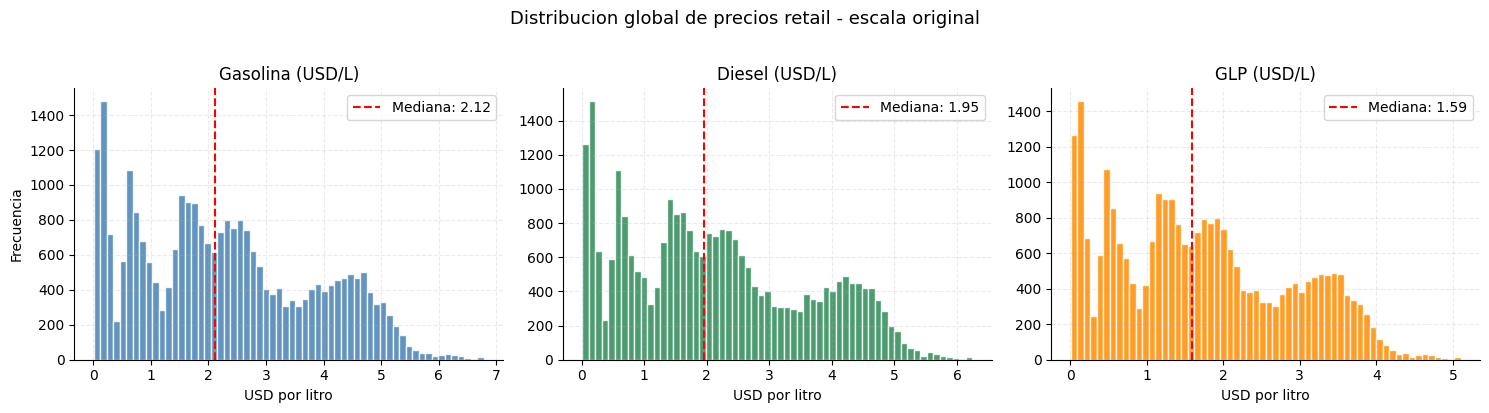

In [94]:
# Panorama de las 3 series de precios retail en escala original
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

price_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']
colors = ['steelblue', 'seagreen', 'darkorange']
titles = ['Gasolina', 'Diesel', 'GLP']

for ax, col, c, t in zip(axes, price_cols, colors, titles):
    # Histograma + linea vertical de la mediana
    ax.hist(df[col], bins=60, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].median(), color='red', linestyle='--', lw=1.5,
               label=f'Mediana: {df[col].median():.2f}')
    ax.set_title(f'{t} (USD/L)')
    ax.set_xlabel('USD por litro')
    ax.set_ylabel('Frecuencia' if ax == axes[0] else '')
    ax.legend()

fig.suptitle('Distribucion global de precios retail - escala original', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Observaciones:**
- Todas las distribuciones son **asimétricas a la derecha** (cola larga hacia precios altos).
- La **mediana** (línea roja) está desplazada hacia la izquierda de la media por esta asimetría.
- Hay una densidad notable de valores muy bajos (<0.5 USD/L) que corresponden a países con
  subsidios extremos.


### 3.2 ¿Hay observaciones con precio cercano a cero?

Queremos entender qué países generan esa cola izquierda con precios cerca de 0 USD/L.


In [95]:
# Filtramos observaciones con precio muy bajo de gasolina
muy_bajo = df[df['petrol_usd_liter'] < 0.10]
print(f'Observaciones con gasolina < 0.10 USD/L: {len(muy_bajo):,}')

# Ver que paises concentran estos casos
print('\nPaises con mas observaciones de precio muy bajo:')
print(muy_bajo['country'].value_counts().head(10))


Observaciones con gasolina < 0.10 USD/L: 1,073

Paises con mas observaciones de precio muy bajo:
country
Iran            327
Venezuela       327
Libya           315
Algeria          41
Iraq             24
Egypt            15
Kuwait           11
Nigeria           8
Qatar             4
Saudi Arabia      1
Name: count, dtype: int64


Paises a graficar: ['Iran', 'Venezuela', 'Libya', 'Algeria', 'Iraq', 'Egypt']


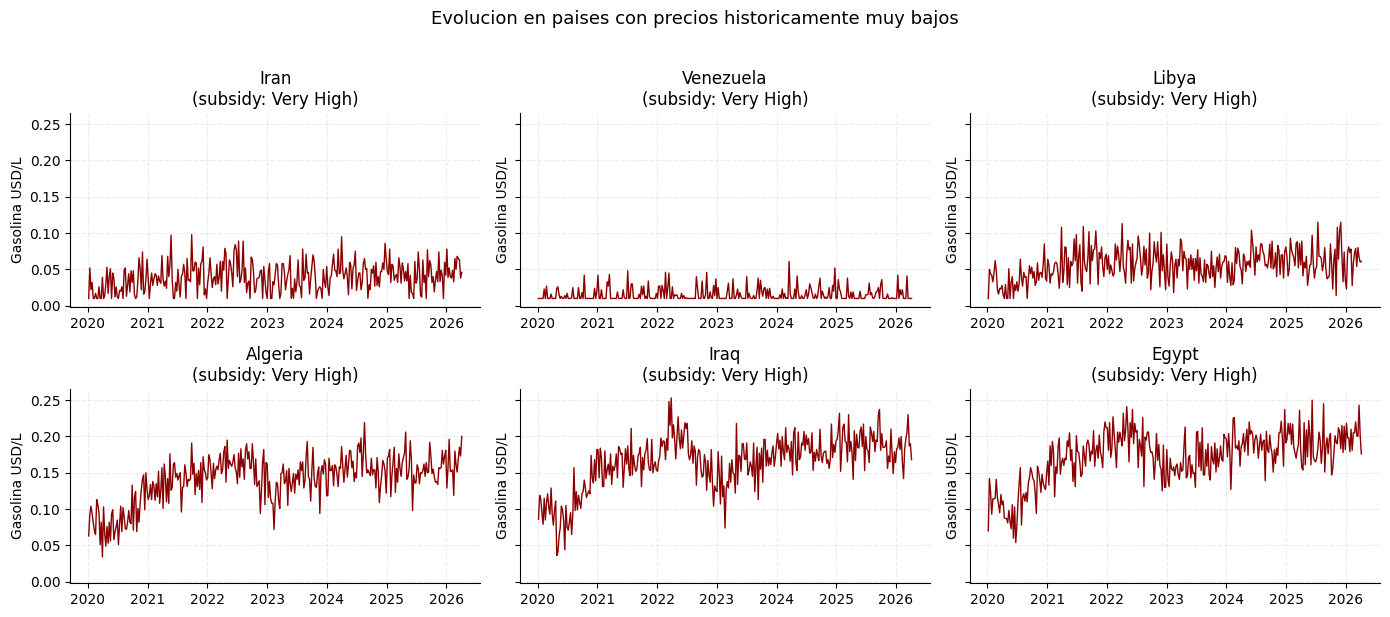

In [96]:
# Visualizamos las series de precio de estos paises "extremos" en el tiempo
paises_extremos = muy_bajo['country'].value_counts().head(6).index.tolist()
print(f'Paises a graficar: {paises_extremos}')

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for ax, country in zip(axes.flatten(), paises_extremos):
    sub = df[df['country'] == country].sort_values('date')
    ax.plot(sub['date'], sub['petrol_usd_liter'], color='darkred', lw=1)
    ax.set_title(f'{country}\n(subsidy: {sub["subsidy_level"].iloc[0]})')
    ax.set_ylabel('Gasolina USD/L')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Evolucion en paises con precios historicamente muy bajos', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Interpretación**: los precios extremadamente bajos se concentran en **Venezuela, Libia,
Iran, Egipto, Kuwait** y otros con subsidios muy altos. No son errores de datos: reflejan
políticas de subsidio estructurales donde el Estado fija precios muy por debajo del costo de
producción. Los **mantenemos** porque son parte del fenómeno que estudiamos.


### 3.3 Detección formal de outliers con z-score robusto (MAD)

El **z-score clásico** (basado en media y desviación estándar) es muy sensible a outliers.
Usamos la versión robusta con la **mediana** y la **MAD (Median Absolute Deviation)**:

$$z_{robust} = 0.6745 \times \frac{x - \text{mediana}}{\text{MAD}}$$

El factor 0.6745 hace que el resultado sea comparable con un z-score estándar bajo normalidad.


In [97]:
def robust_z_scores(df: pd.DataFrame, target: str = 'petrol_usd_liter',
                    threshold: float = 5.0) -> pd.DataFrame:
    '''
    Calcula z-scores robustos por pais y retorna las filas con |z| > threshold.
    El calculo se hace POR PAIS para respetar la heterogeneidad: un precio que es
    tipico en Alemania puede ser anomalo en Venezuela.
    '''
    anomalias = []
    for country, sub in df.groupby('country', observed=True):
        x = sub[target].dropna()
        if len(x) < 20:
            continue
        med = x.median()
        mad = (x - med).abs().median()
        if mad == 0:
            continue  # No hay variabilidad, skip
        z = 0.6745 * (sub[target] - med) / mad
        mask = z.abs() > threshold
        if mask.any():
            hit = sub[mask].copy()
            hit['robust_z'] = z[mask]
            anomalias.append(hit[['country', 'date', target, 'robust_z']])
    if not anomalias:
        return pd.DataFrame()
    return (pd.concat(anomalias, ignore_index=True)
              .sort_values('robust_z', key=lambda s: s.abs(), ascending=False))


# Aplicamos la deteccion
anom = robust_z_scores(df, 'petrol_usd_liter', threshold=5.0)
print(f'Observaciones con |robust_z| > 5: {len(anom)}')
print('\nTop 10 mas extremas:')
print(anom.head(10).to_string(index=False))


Observaciones con |robust_z| > 5: 198

Top 10 mas extremas:
 country       date  petrol_usd_liter  robust_z
 Tunisia 2020-04-27            0.2470   -5.9432
     UAE 2020-04-27            0.3740   -5.8622
     UAE 2020-04-20            0.3970   -5.6341
  Uganda 2020-04-27            1.0300   -5.6117
Ethiopia 2020-04-27            0.6050   -5.5977
 Ecuador 2020-04-20            0.2300   -5.5909
 Ecuador 2020-04-27            0.2310   -5.5759
 Tunisia 2020-05-04            0.2800   -5.5233
  Russia 2020-04-27            0.3020   -5.4907
  Uganda 2020-05-04            1.0660   -5.4705


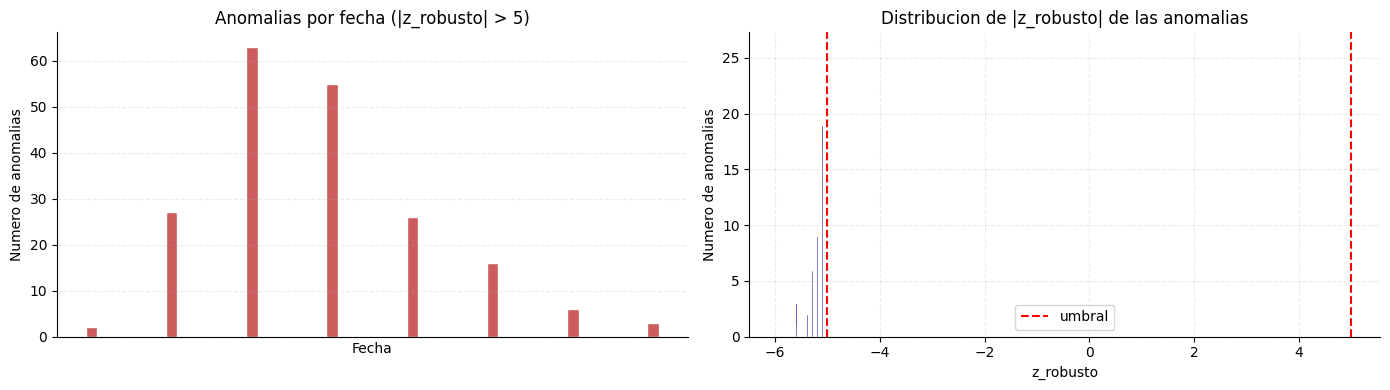

In [98]:
# Visualizamos CUANDO ocurrieron las anomalias (histograma temporal)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Izquierda: distribucion temporal de las anomalias
axes[0].hist(anom['date'], bins=50, color='indianred', edgecolor='white')
axes[0].set_title('Anomalias por fecha (|z_robusto| > 5)')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Numero de anomalias')
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Derecha: distribucion del z-score (para ver cuan extremas son)
axes[1].hist(anom['robust_z'], bins=40, color='darkblue', edgecolor='white')
axes[1].axvline(-5, color='red', ls='--', label='umbral')
axes[1].axvline(5, color='red', ls='--')
axes[1].set_title('Distribucion de |z_robusto| de las anomalias')
axes[1].set_xlabel('z_robusto')
axes[1].set_ylabel('Numero de anomalias')
axes[1].legend()

plt.tight_layout()
plt.show()


**Conclusión clave**: la mayoría de las anomalías se concentran en **abril-mayo 2020**,
el período del colapso COVID. Son **señales reales del shock**, no errores. Por eso
**no se eliminan**.


### 3.4 Retornos semanales extremos

Otra forma de detectar comportamientos atípicos es mirar los **cambios porcentuales
semanales**. Un |Δlog precio| > 30% en una semana es extremadamente grande.


In [99]:
# Calculamos retornos log semanales por pais
def compute_returns(df: pd.DataFrame, price_col: str = 'petrol_usd_liter') -> pd.Series:
    '''Retorno log semanal = log(p_t / p_{t-1}), calculado POR PAIS.'''
    return (df.groupby('country', observed=True)[price_col]
              .transform(lambda s: np.log(s).diff()))


df['dlog_petrol'] = compute_returns(df, 'petrol_usd_liter')

# Filtramos los extremos
ext = df[df['dlog_petrol'].abs() > 0.30].copy()
ext = ext[['country', 'date', 'petrol_usd_liter', 'dlog_petrol',
           'subsidy_level', 'income_level']]
print(f'Retornos extremos (|delta log| > 30%): {len(ext)} observaciones')
print(f'\nDistribucion por nivel de subsidio:')
print(ext['subsidy_level'].value_counts())


Retornos extremos (|delta log| > 30%): 767 observaciones

Distribucion por nivel de subsidio:
subsidy_level
Very High    766
High           1
Low            0
Medium         0
Name: count, dtype: int64


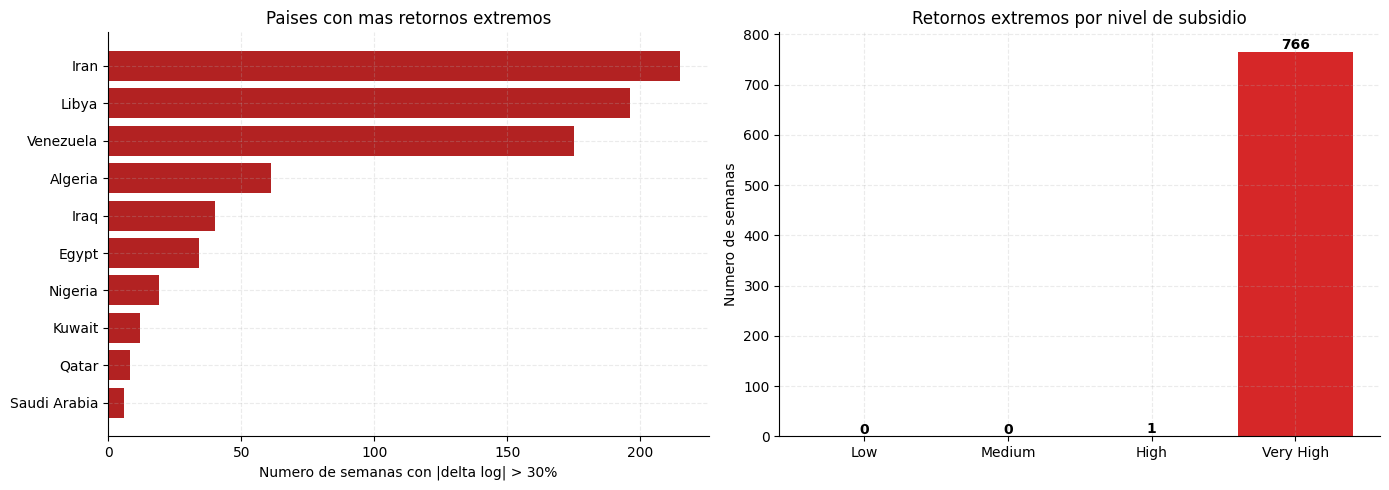

In [100]:
# Visualizamos los retornos extremos por pais y por subsidio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: paises con mas retornos extremos
top_paises = ext['country'].value_counts().head(10)
axes[0].barh(top_paises.index[::-1], top_paises.values[::-1], color='firebrick')
axes[0].set_title('Paises con mas retornos extremos')
axes[0].set_xlabel('Numero de semanas con |delta log| > 30%')

# Derecha: distribucion de los retornos extremos por nivel de subsidio
order = ['Low', 'Medium', 'High', 'Very High']
counts = [ext[ext['subsidy_level'] == lvl].shape[0] for lvl in order]
axes[1].bar(order, counts, color=['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728'])
axes[1].set_title('Retornos extremos por nivel de subsidio')
axes[1].set_ylabel('Numero de semanas')
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Hallazgo muy relevante**: el **100% de los retornos extremos** ocurren en países con
subsidios "Very High". Esto ya nos anticipa la respuesta a PI-2: los subsidios no son un
escudo contra la volatilidad, son una fuente de volatilidad por sus ajustes discretos.


In [101]:
# --- Outlier Handler: politica explicita de manejo de anomalias ---
class OutlierHandler:
    '''Manejo configurable de outliers para datos de panel.'''

    def __init__(self, method='flag', threshold_mad=5.0):
        self.method = method  # 'flag' | 'remove' | 'clip'
        self.threshold = threshold_mad
        self.report = {}

    def detect_and_handle(self, df, target_cols=None):
        '''Detecta outliers por pais con MAD y aplica la estrategia elegida.'''
        if target_cols is None:
            target_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']
        out = df.copy()
        out['is_outlier'] = False

        total_flagged = 0
        for col in target_cols:
            col_flagged = 0
            for country, sub in out.groupby('country', observed=True):
                x = sub[col].dropna()
                if len(x) < 20:
                    continue
                med = x.median()
                mad = (x - med).abs().median()
                if mad == 0:
                    continue
                z = 0.6745 * (sub[col] - med) / mad
                mask = z.abs() > self.threshold
                n_outliers = mask.sum()
                if n_outliers > 0:
                    out.loc[mask[mask].index, 'is_outlier'] = True
                    col_flagged += n_outliers

            self.report[col] = col_flagged
            total_flagged += col_flagged

        print(f'OutlierHandler (method={self.method}, threshold={self.threshold}):')
        for col, n in self.report.items():
            print(f'  {col}: {n} outliers flagged')
        print(f'  Total filas con is_outlier=True: {out["is_outlier"].sum()}')
        print(f'  Politica: {self.method.upper()} (no se eliminan, se marcan para analisis)')
        return out

# Aplicar la politica de outliers
handler = OutlierHandler(method='flag', threshold_mad=5.0)
df = handler.detect_and_handle(df)

OutlierHandler (method=flag, threshold=5.0):
  petrol_usd_liter: 198 outliers flagged
  diesel_usd_liter: 173 outliers flagged
  lpg_usd_liter: 190 outliers flagged
  Total filas con is_outlier=True: 314
  Politica: FLAG (no se eliminan, se marcan para analisis)


### 3.5 Resumen de la limpieza

**Decisiones tomadas:**
- Se agrega columna `is_outlier` para **marcar** anomalias (no eliminar).
- **No se eliminan observaciones** del dataset. Todos los "outliers" son económicamente
  interpretables.
- Los precios muy bajos (< 0.10 USD/L) corresponden a países con subsidios estructurales.
- Los retornos extremos (> 30%) corresponden a ajustes administrativos de esos mismos países.
- Se crea la variable `dlog_petrol` (retorno log semanal) que usaremos en análisis posteriores.


## 4. EDA univariado

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × 18 (nuevo: dlog_petrol) columnas  
> **Descripción**: Panel completo con todas las variables. Esta sección profundiza en la distribución univariada de cada variable importante.


### 4.1 Estadísticas descriptivas principales


In [102]:
# Estadisticas descriptivas compactas de las variables numericas clave
cols_num = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter',
            'brent_crude_usd', 'tax_percentage', 'ovx', 'dxy', 'gpr']
desc = df[cols_num].describe().T.round(3)
desc['skewness'] = [stats.skew(df[c].dropna()) for c in cols_num]
desc['kurtosis'] = [stats.kurtosis(df[c].dropna()) for c in cols_num]
print('Estadisticas descriptivas (incluye skewness y kurtosis):')
print(desc)


Estadisticas descriptivas (incluye skewness y kurtosis):
                      count     mean     std      min      25%      50%      75%      max  skewness  kurtosis
petrol_usd_liter 27468.0000   2.2820  1.5410   0.0100   0.9260   2.1170   3.4570   6.7790    0.3706   -0.8452
diesel_usd_liter 27468.0000   2.1340  1.4650   0.0100   0.8580   1.9540   3.2310   6.2400    0.3989   -0.8654
lpg_usd_liter    27468.0000   1.7110  1.1560   0.0100   0.6950   1.5880   2.5900   5.1000    0.3709   -0.8451
brent_crude_usd  27468.0000 106.6860 18.9720  47.9700 101.1400 112.2700 119.4100 130.0000   -1.4125    1.3373
tax_percentage   27468.0000  26.7740 17.2030   0.0000  13.5000  23.4000  38.9000  65.0000    0.5663   -0.6810
ovx              27468.0000  44.1570 21.7410  24.1000  33.9770  38.0990  47.0090 213.2770    4.0675   20.6956
dxy              27468.0000 119.5580  4.2980 110.7240 116.1340 120.0850 122.4210 129.3780   -0.1003   -0.5054
gpr              27468.0000 123.7680 48.7130  58.4200  86.5700 

**Observaciones del resumen:**
- Los precios retail tienen **skewness positiva** (cola derecha larga).
- Las variables exógenas (OVX, GPR) tienen **kurtosis muy alta** → colas pesadas, eventos
  extremos frecuentes.
- El Brent tiene una distribución más simétrica.

### 4.2 Histogramas y densidades — comparación original vs log-transformada


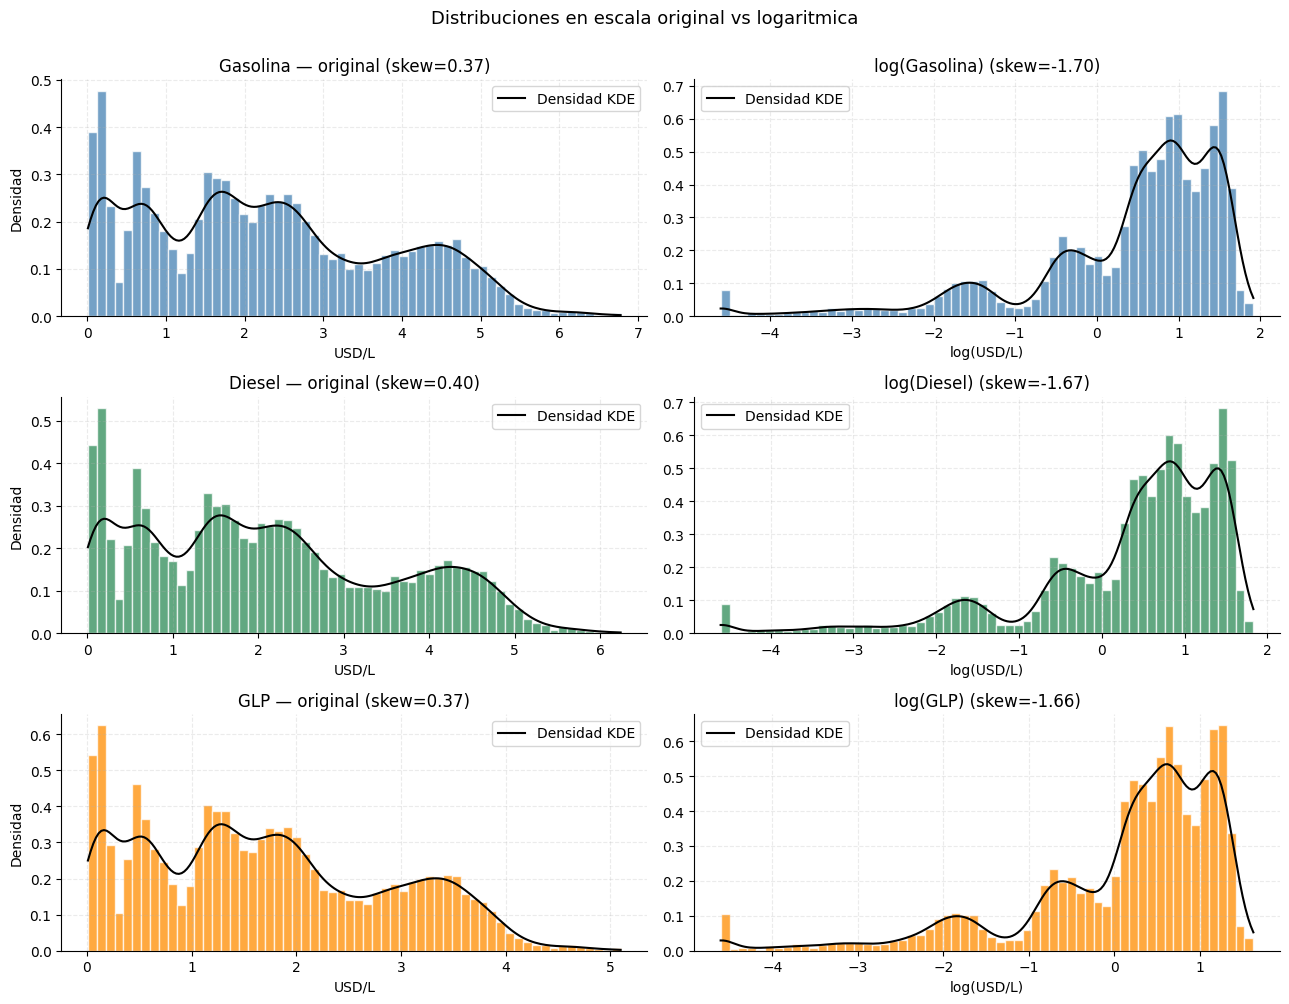

In [103]:
# Para las 3 series de precios, graficamos histograma + densidad y su version log
fig, axes = plt.subplots(3, 2, figsize=(13, 10))

price_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']
titles = ['Gasolina', 'Diesel', 'GLP']
colors = ['steelblue', 'seagreen', 'darkorange']

for i, (col, title, color) in enumerate(zip(price_cols, titles, colors)):
    # ORIGINAL
    axes[i, 0].hist(df[col], bins=60, color=color, edgecolor='white',
                    alpha=0.75, density=True)
    # Superponer densidad KDE
    xs = np.linspace(df[col].min(), df[col].max(), 200)
    kde = stats.gaussian_kde(df[col])
    axes[i, 0].plot(xs, kde(xs), color='black', lw=1.5, label='Densidad KDE')
    sk = stats.skew(df[col])
    axes[i, 0].set_title(f'{title} — original (skew={sk:.2f})')
    axes[i, 0].set_xlabel('USD/L')
    axes[i, 0].set_ylabel('Densidad')
    axes[i, 0].legend()

    # LOG-TRANSFORMADO
    log_vals = np.log(df[col])
    axes[i, 1].hist(log_vals, bins=60, color=color, edgecolor='white',
                    alpha=0.75, density=True)
    xs_log = np.linspace(log_vals.min(), log_vals.max(), 200)
    kde_log = stats.gaussian_kde(log_vals)
    axes[i, 1].plot(xs_log, kde_log(xs_log), color='black', lw=1.5, label='Densidad KDE')
    sk_log = stats.skew(log_vals)
    axes[i, 1].set_title(f'log({title}) (skew={sk_log:.2f})')
    axes[i, 1].set_xlabel('log(USD/L)')
    axes[i, 1].legend()

fig.suptitle('Distribuciones en escala original vs logaritmica', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()


**Justificación de la transformación log**:
- La skewness baja de ~0.6 a casi 0 (distribución casi simétrica).
- Las distribuciones logarítmicas son casi gaussianas, lo que justifica usar métodos
  basados en el supuesto de normalidad.
- En los modelos econométricos los coeficientes sobre log-precios se interpretan como
  **elasticidades** (% cambio en precio sobre % cambio en Brent).

### 4.3 Distribución del Brent en el tiempo


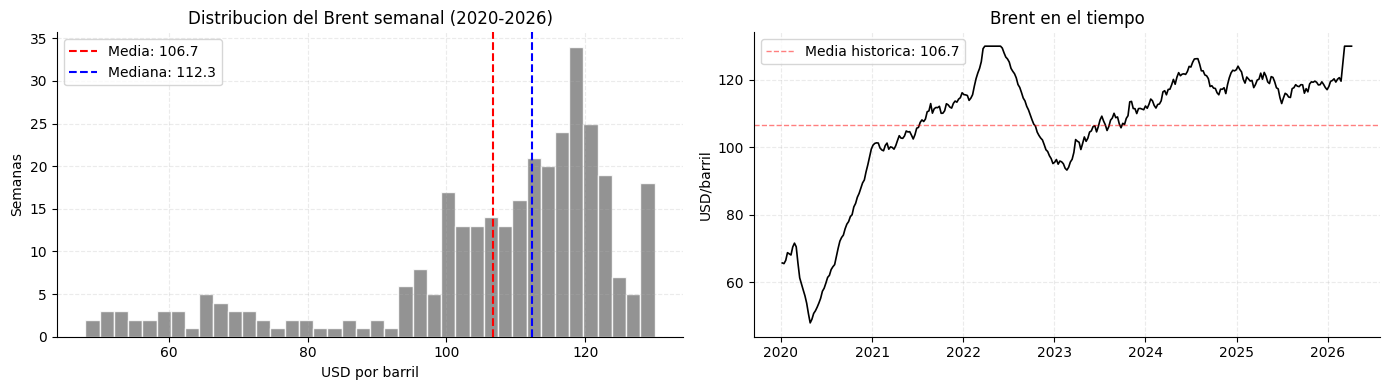

In [104]:
# Brent: histograma + serie temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Izquierda: histograma
brent_unique = df.drop_duplicates('date')['brent_crude_usd']
axes[0].hist(brent_unique, bins=40, color='gray', edgecolor='white', alpha=0.85)
axes[0].axvline(brent_unique.mean(), color='red', ls='--', lw=1.5,
                label=f'Media: {brent_unique.mean():.1f}')
axes[0].axvline(brent_unique.median(), color='blue', ls='--', lw=1.5,
                label=f'Mediana: {brent_unique.median():.1f}')
axes[0].set_title('Distribucion del Brent semanal (2020-2026)')
axes[0].set_xlabel('USD por barril')
axes[0].set_ylabel('Semanas')
axes[0].legend()

# Derecha: serie temporal
fechas_unicas = df.drop_duplicates('date').sort_values('date')
axes[1].plot(fechas_unicas['date'], fechas_unicas['brent_crude_usd'],
             color='black', lw=1.2)
axes[1].axhline(brent_unique.mean(), color='red', ls='--', lw=1, alpha=0.5,
                label=f'Media historica: {brent_unique.mean():.1f}')
axes[1].set_title('Brent en el tiempo')
axes[1].set_ylabel('USD/barril')
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.4 Distribuciones de las variables exógenas (OVX, DXY, GPR)


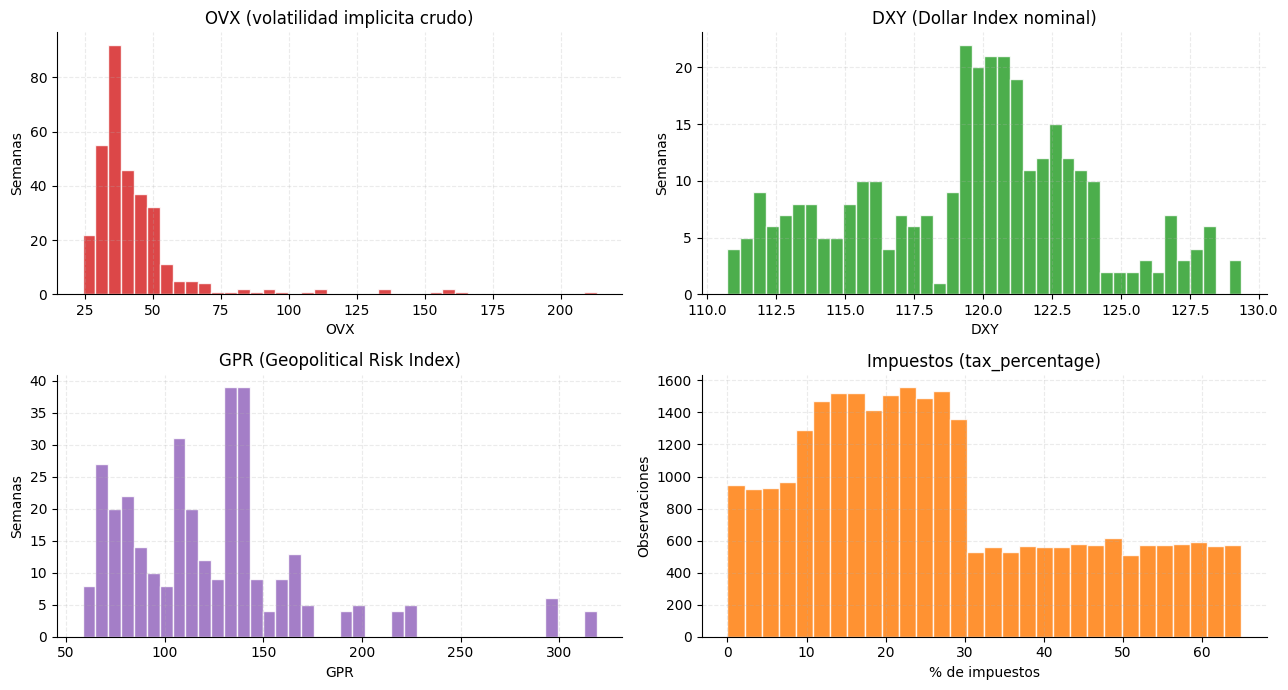

In [105]:
# Variables exogenas: distribucion univariada
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# OVX (volatilidad implicita crudo)
axes[0, 0].hist(df.drop_duplicates('date')['ovx'], bins=40,
                color='#d62728', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('OVX (volatilidad implicita crudo)')
axes[0, 0].set_xlabel('OVX')
axes[0, 0].set_ylabel('Semanas')

# DXY (Dollar Index)
axes[0, 1].hist(df.drop_duplicates('date')['dxy'], bins=40,
                color='#2ca02c', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('DXY (Dollar Index nominal)')
axes[0, 1].set_xlabel('DXY')
axes[0, 1].set_ylabel('Semanas')

# GPR
axes[1, 0].hist(df.drop_duplicates('date')['gpr'], bins=40,
                color='#9467bd', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('GPR (Geopolitical Risk Index)')
axes[1, 0].set_xlabel('GPR')
axes[1, 0].set_ylabel('Semanas')

# Tax percentage (impuestos)
axes[1, 1].hist(df.drop_duplicates(['country', 'date'])['tax_percentage'],
                bins=30, color='#ff7f0e', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Impuestos (tax_percentage)')
axes[1, 1].set_xlabel('% de impuestos')
axes[1, 1].set_ylabel('Observaciones')

plt.tight_layout()
plt.show()


### 4.5 Distribución de los retornos semanales (dlog_petrol)


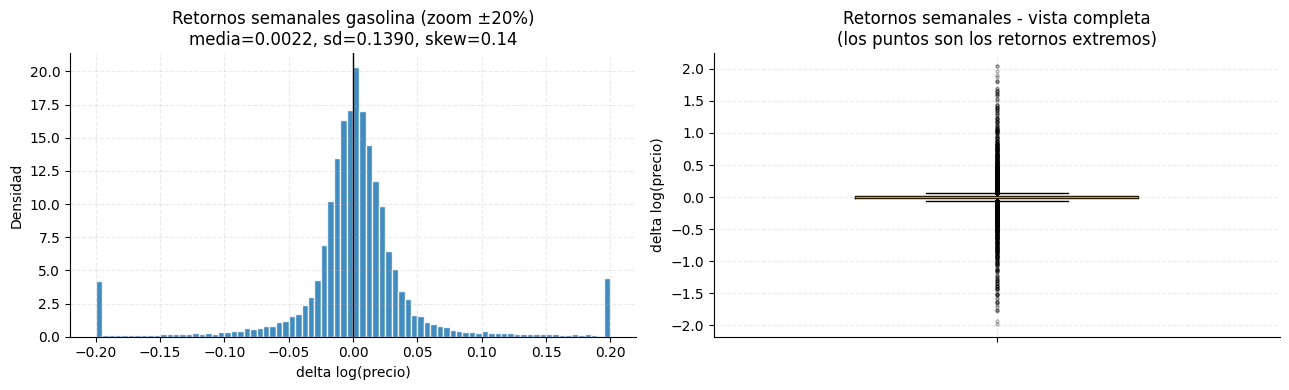

In [106]:
# Los retornos log son la variable clave para medir volatilidad y pass-through
returns = df['dlog_petrol'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Izquierda: histograma con zoom (excluye colas extremas)
axes[0].hist(returns.clip(-0.2, 0.2), bins=80, color='#1f77b4',
             edgecolor='white', alpha=0.85, density=True)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title(f'Retornos semanales gasolina (zoom ±20%)\n'
                  f'media={returns.mean():.4f}, sd={returns.std():.4f}, '
                  f'skew={stats.skew(returns):.2f}')
axes[0].set_xlabel('delta log(precio)')
axes[0].set_ylabel('Densidad')

# Derecha: boxplot sin zoom (para ver outliers)
axes[1].boxplot(returns, vert=True, widths=0.5,
                flierprops=dict(markersize=2, alpha=0.3))
axes[1].set_title('Retornos semanales - vista completa\n(los puntos son los retornos extremos)')
axes[1].set_ylabel('delta log(precio)')
axes[1].set_xticklabels([''])

plt.tight_layout()
plt.show()


**Los retornos tienen colas extremadamente pesadas** (kurtosis alta) — la mayoría son
muy pequeños (<5%) pero hay un puñado de observaciones extremas (>100%) que corresponden
a países con subsidios muy altos.


## 5. EDA bivariado y temporal

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × 18 columnas  
> **Descripción**: Panel enriquecido. Buscamos relaciones entre pares de variables y su dinámica conjunta en el tiempo.


### 5.1 Matriz de correlaciones


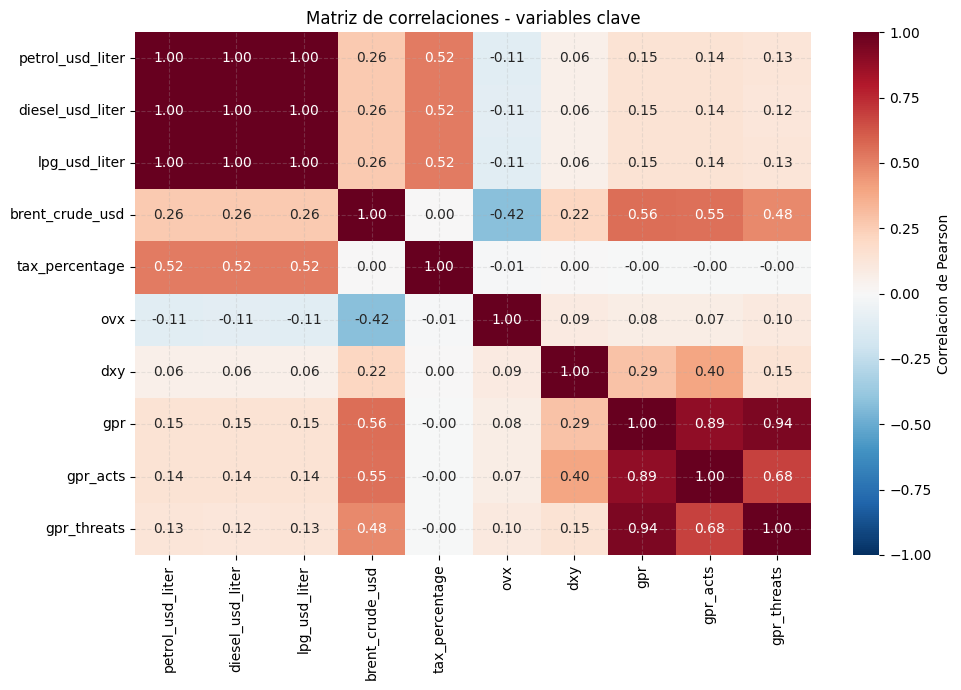

In [107]:
# Matriz de correlaciones con las variables numericas clave
corr_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter',
             'brent_crude_usd', 'tax_percentage', 'ovx', 'dxy',
             'gpr', 'gpr_acts', 'gpr_threats']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=False,
            cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Matriz de correlaciones - variables clave')
plt.tight_layout()
plt.show()


**Lecturas clave:**
- Las 3 series de precios retail están **muy correlacionadas entre sí** (>0.93).
- El Brent tiene correlación moderada con los retail (~0.27) **en niveles** — la correlación
  será mucho más fuerte en retornos (la veremos en PI-3).
- **DXY y Brent negativamente correlacionados** (~-0.55): dólar fuerte ↔ crudo barato.
- **GPR correlacionado positivamente con Brent** (~0.4): riesgo geopolítico eleva el crudo.

### 5.2 Evolución temporal global con regímenes de shock


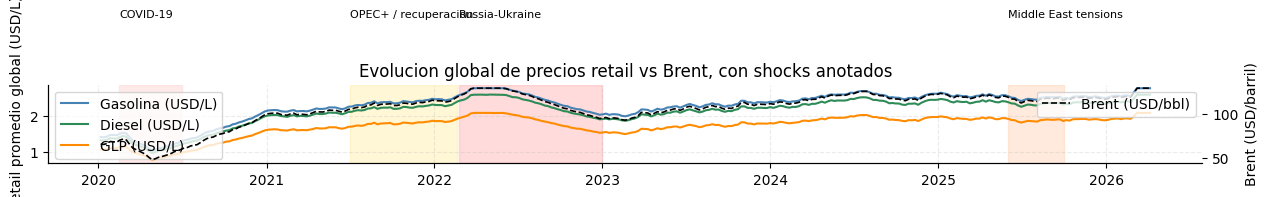

In [108]:
# Promedio global semanal de cada combustible + Brent
weekly = (df.groupby('date')
            .agg(petrol=('petrol_usd_liter', 'mean'),
                 diesel=('diesel_usd_liter', 'mean'),
                 lpg=('lpg_usd_liter', 'mean'),
                 brent=('brent_crude_usd', 'mean'))
            .reset_index())

# Periodos de shock identificados en la literatura
shocks = [
    ('2020-02-15', '2020-06-30', 'COVID-19', '#ffcccc'),
    ('2021-07-01', '2022-02-20', 'OPEC+ / recuperacion', '#ffeb99'),
    ('2022-02-24', '2022-12-31', 'Russia-Ukraine', '#ffa5a5'),
    ('2025-06-01', '2025-09-30', 'Middle East tensions', '#ffccaa'),
]

fig, ax1 = plt.subplots(figsize=(13, 5))
# Sombrear los shocks
for inicio, fin, nombre, color in shocks:
    ax1.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), color=color, alpha=0.4)
    ax1.text(pd.Timestamp(inicio), ax1.get_ylim()[1] * 0.95 if False else 5.0,
             nombre, fontsize=8, rotation=0, va='top')

# Precios retail
ax1.plot(weekly['date'], weekly['petrol'], color='steelblue', lw=1.5,
         label='Gasolina (USD/L)')
ax1.plot(weekly['date'], weekly['diesel'], color='seagreen', lw=1.5,
         label='Diesel (USD/L)')
ax1.plot(weekly['date'], weekly['lpg'], color='darkorange', lw=1.5,
         label='GLP (USD/L)')
ax1.set_ylabel('Precio retail promedio global (USD/L)')
ax1.set_xlabel('')
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.legend(loc='upper left')

# Brent en eje derecho
ax2 = ax1.twinx()
ax2.plot(weekly['date'], weekly['brent'], color='black', lw=1.2, ls='--',
         label='Brent (USD/bbl)')
ax2.set_ylabel('Brent (USD/barril)')
ax2.legend(loc='upper right')
ax2.grid(False)

plt.title('Evolucion global de precios retail vs Brent, con shocks anotados')
plt.tight_layout()
plt.show()


**Narrativa**: el paralelismo entre retail y Brent es muy claro a nivel agregado
(sugiere pass-through alto). Los cinco shocks identificados se perciben claramente:
- **COVID** hundió los precios en abril 2020.
- **OPEC+ / recuperación** sostuvo el alza.
- **Russia-Ukraine** marcó el pico histórico (~130 USD/bbl).
- **Normalización** en 2023-2024.
- **Tensiones Medio Oriente** al final del período.

### 5.3 Series exógenas en los mismos regímenes


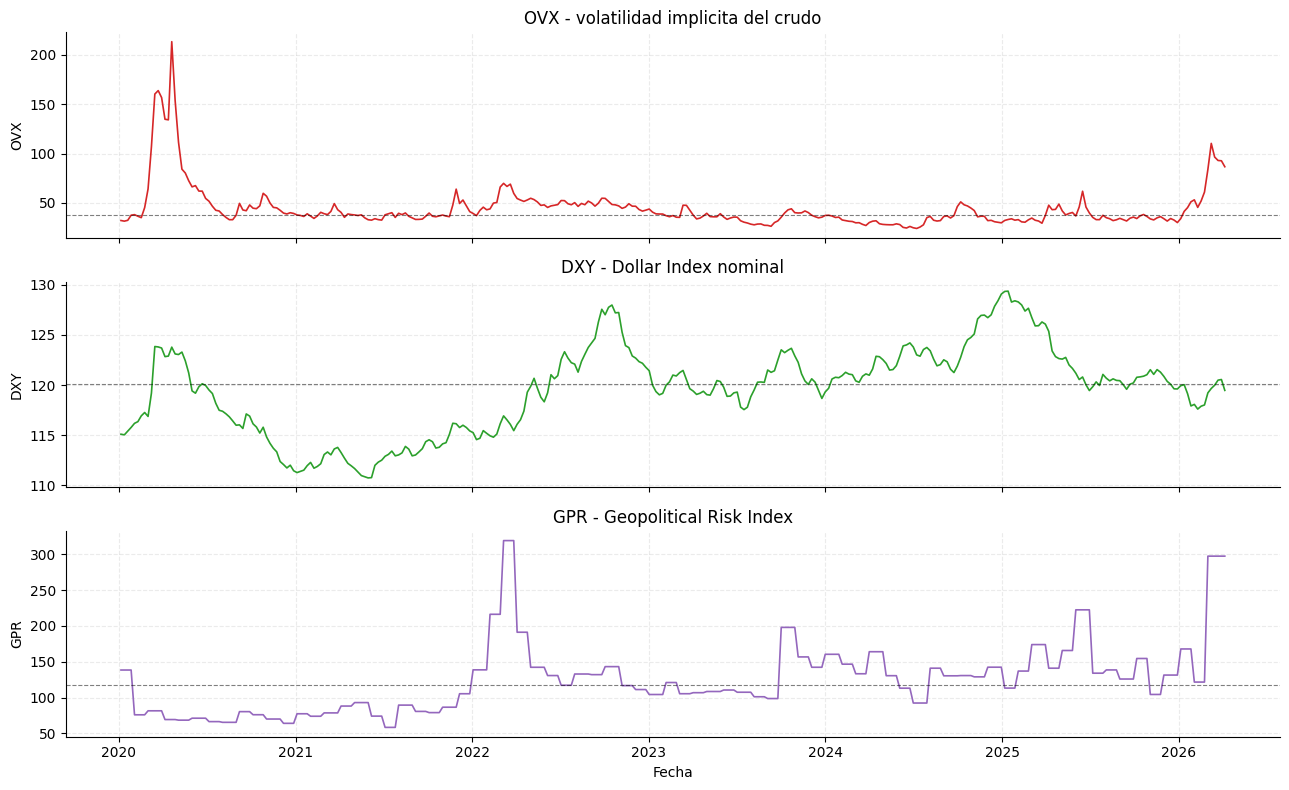

In [109]:
# Graficar OVX, DXY, GPR en paralelo
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

# OVX
axes[0].plot(weekly['date'].values,
             df.groupby('date')['ovx'].first().values, color='#d62728', lw=1.2)
axes[0].axhline(df['ovx'].median(), color='black', ls='--', lw=0.8, alpha=0.5)
axes[0].set_title('OVX - volatilidad implicita del crudo')
axes[0].set_ylabel('OVX')

# DXY
axes[1].plot(weekly['date'].values,
             df.groupby('date')['dxy'].first().values, color='#2ca02c', lw=1.2)
axes[1].axhline(df['dxy'].median(), color='black', ls='--', lw=0.8, alpha=0.5)
axes[1].set_title('DXY - Dollar Index nominal')
axes[1].set_ylabel('DXY')

# GPR
axes[2].plot(weekly['date'].values,
             df.groupby('date')['gpr'].first().values, color='#9467bd', lw=1.2)
axes[2].axhline(df['gpr'].median(), color='black', ls='--', lw=0.8, alpha=0.5)
axes[2].set_title('GPR - Geopolitical Risk Index')
axes[2].set_ylabel('GPR')
axes[2].set_xlabel('Fecha')
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


## 6. EDA por grupos: heterogeneidad estructural

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × 18 columnas  
> **Descripción**: Mismo panel, pero ahora desagregando por región, nivel de ingreso y nivel de subsidio para visualizar heterogeneidad.


### 6.1 Estructura de los grupos


In [110]:
# Tabla cruzada: cuantos paises por combinacion (income x subsidy)
# Necesitamos un pais por fila (no semanas)
df_countries = df.drop_duplicates('country')[['country', 'region', 'income_level', 'subsidy_level']]
tab = pd.crosstab(df_countries['income_level'], df_countries['subsidy_level'])
print('Distribucion de 84 paises por (income_level x subsidy_level):')
print(tab)
print(f'\nTotal: {tab.sum().sum()} paises')


Distribucion de 84 paises por (income_level x subsidy_level):
subsidy_level  Low  Medium  High  Very High
income_level                               
Low              8       7     4          4
Middle           8      11     7          3
High            28       0     1          3

Total: 84 paises


In [111]:
# Distribucion por region
print('\nPaises por region:')
print(df_countries['region'].value_counts())



Paises por region:
region
Africa           23
Europe           23
Asia             17
Middle East       9
South America     7
North America     3
Oceania           2
Name: count, dtype: int64


### 6.2 Precio promedio por grupos — boxplots


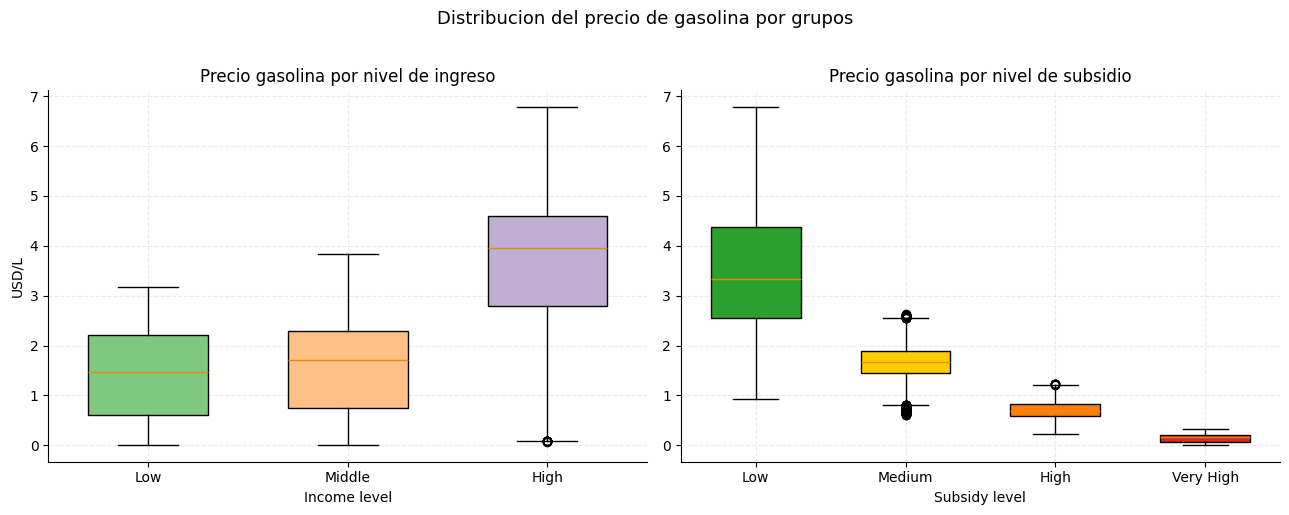

In [112]:
# Boxplots por income_level y subsidy_level
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por income_level
order_inc = ['Low', 'Middle', 'High']
data_inc = [df[df['income_level'] == lvl]['petrol_usd_liter'].values for lvl in order_inc]
bp1 = axes[0].boxplot(data_inc, labels=order_inc, patch_artist=True, widths=0.6)
for patch, color in zip(bp1['boxes'], ['#7fc97f', '#fdc086', '#beaed4']):
    patch.set_facecolor(color)
axes[0].set_title('Precio gasolina por nivel de ingreso')
axes[0].set_ylabel('USD/L')
axes[0].set_xlabel('Income level')

# Por subsidy_level
order_sub = ['Low', 'Medium', 'High', 'Very High']
data_sub = [df[df['subsidy_level'] == lvl]['petrol_usd_liter'].values for lvl in order_sub]
bp2 = axes[1].boxplot(data_sub, labels=order_sub, patch_artist=True, widths=0.6)
for patch, color in zip(bp2['boxes'], ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728']):
    patch.set_facecolor(color)
axes[1].set_title('Precio gasolina por nivel de subsidio')
axes[1].set_xlabel('Subsidy level')
axes[1].set_ylabel('')

fig.suptitle('Distribucion del precio de gasolina por grupos', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 6.3 Densidades superpuestas por nivel de subsidio

Los boxplots resumen; las densidades muestran la forma completa.


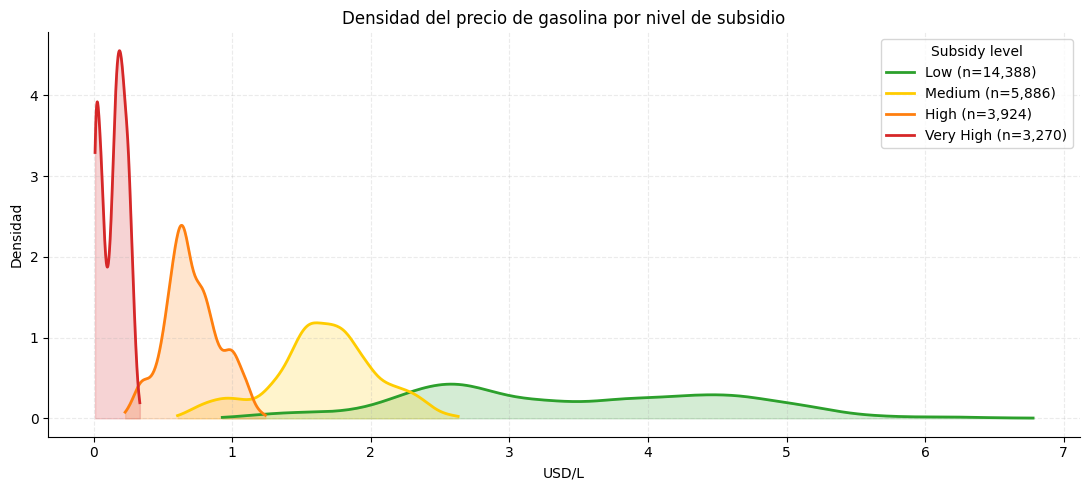

In [113]:
# Densidades superpuestas para ver la forma de cada distribucion
fig, ax = plt.subplots(figsize=(11, 5))

order_sub = ['Low', 'Medium', 'High', 'Very High']
colors = ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728']

for lvl, color in zip(order_sub, colors):
    data = df[df['subsidy_level'] == lvl]['petrol_usd_liter']
    # KDE sobre log para ver mejor las colas
    xs = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(xs, kde(xs), color=color, lw=2, label=f'{lvl} (n={len(data):,})')
    ax.fill_between(xs, kde(xs), alpha=0.2, color=color)

ax.set_title('Densidad del precio de gasolina por nivel de subsidio')
ax.set_xlabel('USD/L')
ax.set_ylabel('Densidad')
ax.legend(title='Subsidy level')
plt.tight_layout()
plt.show()


**Observación**: la diferencia entre `Very High` y `Low` es dramática. `Very High` está
casi todo concentrado cerca de 0 USD/L; `Low` tiene una distribución mucho más dispersa
y centrada cerca de 2 USD/L.

### 6.4 Precio por región (evolución temporal)


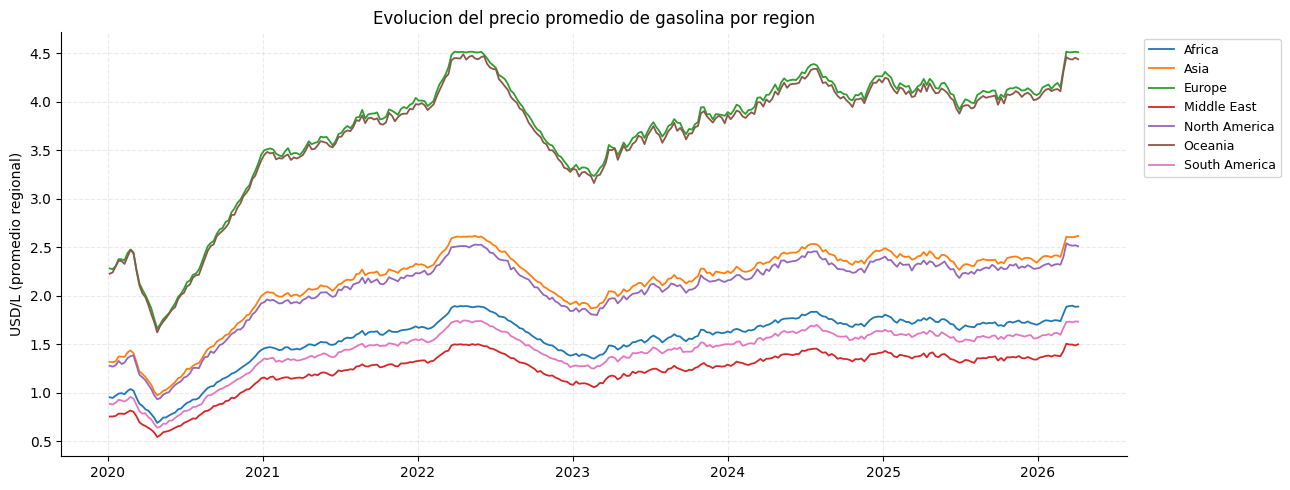

In [114]:
# Promedio de precio por region en el tiempo
regional = (df.groupby(['date', 'region'], observed=True)['petrol_usd_liter']
              .mean()
              .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
regiones = sorted(df['region'].unique())
colors = sns.color_palette('tab10', n_colors=len(regiones))

for region, color in zip(regiones, colors):
    sub = regional[regional['region'] == region]
    ax.plot(sub['date'], sub['petrol_usd_liter'], label=region, lw=1.3, color=color)

ax.set_title('Evolucion del precio promedio de gasolina por region')
ax.set_ylabel('USD/L (promedio regional)')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


### 6.5 Volatilidad anualizada por subsidio (preview de PI-2)


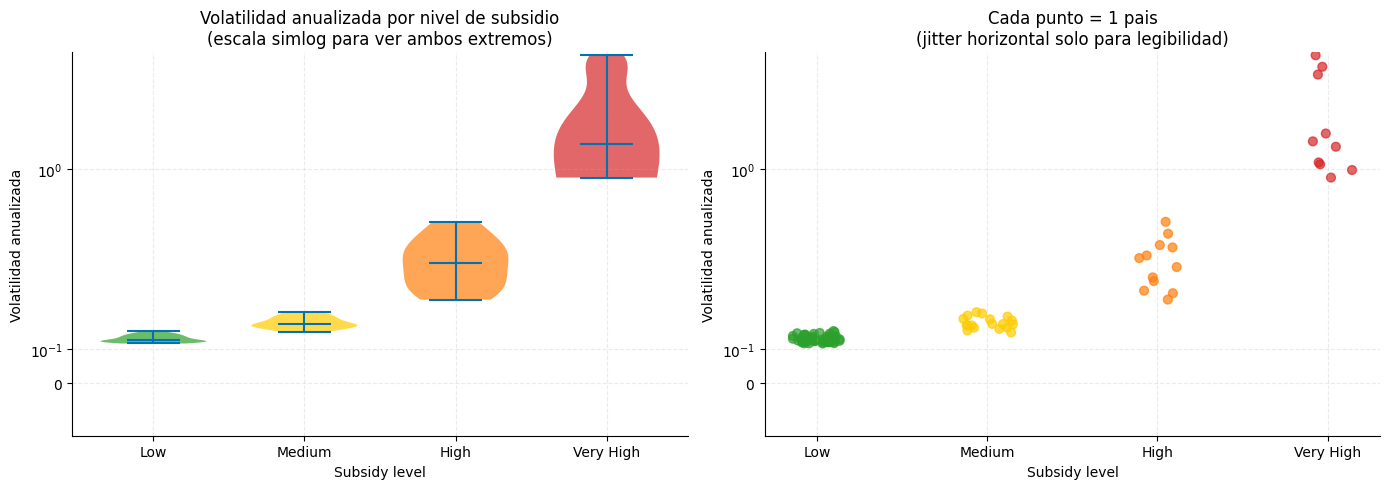


Mediana de volatilidad por subsidio:
subsidy_level
Low         0.1290
Medium      0.1750
High        0.3570
Very High   1.4550
Name: vol_anual, dtype: float64


In [115]:
# Volatilidad anualizada por pais y subsidio
vol_por_pais = (df.groupby(['country', 'subsidy_level'], observed=True)['dlog_petrol']
                  .std() * np.sqrt(52)).reset_index(name='vol_anual')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: violin plot por subsidio
order = ['Low', 'Medium', 'High', 'Very High']
data_vol = [vol_por_pais[vol_por_pais['subsidy_level'] == lvl]['vol_anual'].values
            for lvl in order]
parts = axes[0].violinplot(data_vol, showmedians=True, widths=0.7)
for pc, color in zip(parts['bodies'], ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order)
axes[0].set_yscale('symlog', linthresh=0.5)
axes[0].set_title('Volatilidad anualizada por nivel de subsidio\n(escala simlog para ver ambos extremos)')
axes[0].set_xlabel('Subsidy level')
axes[0].set_ylabel('Volatilidad anualizada')

# Derecha: scatter de cada pais
jitter = np.random.uniform(-0.15, 0.15, size=len(vol_por_pais))
x_map = {lvl: i for i, lvl in enumerate(order)}
x_vals = [x_map[lvl] + j for lvl, j in zip(vol_por_pais['subsidy_level'], jitter)]
color_map = {'Low': '#2ca02c', 'Medium': '#ffcc00', 'High': '#ff7f0e', 'Very High': '#d62728'}
colors_scatter = [color_map[lvl] for lvl in vol_por_pais['subsidy_level']]
axes[1].scatter(x_vals, vol_por_pais['vol_anual'], c=colors_scatter, alpha=0.7, s=40)
axes[1].set_xticks(range(len(order)))
axes[1].set_xticklabels(order)
axes[1].set_yscale('symlog', linthresh=0.5)
axes[1].set_title('Cada punto = 1 pais\n(jitter horizontal solo para legibilidad)')
axes[1].set_xlabel('Subsidy level')
axes[1].set_ylabel('Volatilidad anualizada')

plt.tight_layout()
plt.show()

print('\nMediana de volatilidad por subsidio:')
print(vol_por_pais.groupby('subsidy_level', observed=True)['vol_anual'].median().round(3))


**Hallazgo central**: contrario a la hipótesis inicial, los países "Very High" tienen
la **MAYOR volatilidad** (mediana ≈ 1.45 vs 0.13 en "Low"). Esto se formalizará en PI-2.


## 7. Ingeniería de variables

Construimos las variables derivadas necesarias para los modelos econométricos y predictivos.

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × ~55 (antes: 18) columnas  
> **Descripción**: Panel enriquecido con variables transformadas: logs, lags del Brent, descomposición Mork asimétrica, NOPI de Hamilton, medias móviles, volatilidad rolling, variables temporales.


In [116]:
# === Configuracion centralizada de feature engineering ===
class FeatureConfig:
    '''Parametros centralizados para ingenieria de variables.'''

    # Ventanas para medias moviles (semanas)
    MA_WINDOWS = [4, 12]

    # Ventanas para volatilidad rolling (semanas)
    VOL_WINDOWS = [4, 12, 52]

    # Ordenes de rezago (semanas)
    LAG_ORDERS = [1, 2, 3, 4]

    # Ventana NOPI Hamilton (semanas)
    NOPI_WINDOW = 52

    # Conversiones de unidades (con fuente)
    BARRELS_TO_GALLONS = 42.0   # 1 barril = 42 galones US (estandar NYMEX)
    GALLONS_TO_LITERS = 3.785   # 1 galon = 3.785 litros

    # Umbrales
    MIN_PRICE_FOR_LOG = 0.01    # USD/L: precios menores se clipean antes de log
    ROBUST_Z_THRESHOLD = 5.0    # Umbral MAD para outliers

    # Columnas de precio
    PRICE_COLS = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd']


class PanelOps:
    '''Helper para operaciones within-panel (evita repetir groupby).'''

    def __init__(self, df, groupby_col='country', observed=True):
        self._df = df
        self._col = groupby_col
        self._obs = observed

    def _gb(self, series_name):
        return self._df.groupby(self._col, observed=self._obs)[series_name]

    def shift(self, series_name, k):
        return self._gb(series_name).shift(k)

    def diff(self, series_name):
        return self._gb(series_name).diff()

    def transform(self, series_name, func):
        return self._gb(series_name).transform(func)

    def rolling_mean(self, series_name, window):
        return self._gb(series_name).transform(
            lambda s: s.rolling(window, min_periods=1).mean())

    def rolling_std(self, series_name, window, min_periods=2):
        return self._gb(series_name).transform(
            lambda s: s.rolling(window, min_periods=min_periods).std())


cfg = FeatureConfig()
print(f'FeatureConfig: MA={cfg.MA_WINDOWS}, VOL={cfg.VOL_WINDOWS}, '
      f'LAGS={cfg.LAG_ORDERS}, NOPI={cfg.NOPI_WINDOW}')

FeatureConfig: MA=[4, 12], VOL=[4, 12, 52], LAGS=[1, 2, 3, 4], NOPI=52


In [ ]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    '''
    Agrega las variables derivadas al panel. Todo se calcula POR PAIS.
    Usa FeatureConfig para parametros y PanelOps para operaciones de panel.

    Grupos de variables:
    1. Log-precios (con safeguard para precios <= 0)
    2. Lags y log-diferencias del Brent
    3. Descomposicion Mork (simetrica/asimetrica)
    4. NOPI Hamilton
    5. Retornos y lags de gasolina
    6. Medias moviles
    7. Volatilidad rolling
    8. Variables temporales
    9. Features FRED extra (crack spread, spreads, inventarios)
    '''
    out = df.copy().sort_values(['country', 'date']).reset_index(drop=True)
    ops = PanelOps(out)

    # === 1. LOGS (con safeguard) ===
    for col in cfg.PRICE_COLS:
        alias = col.split("_")[0]
        # Clip precios <= 0 para evitar -inf en log
        safe_vals = out[col].clip(lower=cfg.MIN_PRICE_FOR_LOG)
        n_clipped = (out[col] <= 0).sum()
        if n_clipped > 0:
            print(f'  ⚠ {col}: {n_clipped} valores <= 0 clipeados a {cfg.MIN_PRICE_FOR_LOG}')
        out[f'log_{alias}'] = np.log(safe_vals)
        # Verificar que no hay NaN/inf introducidos
        n_bad = np.isinf(out[f'log_{alias}']).sum() + out[f'log_{alias}'].isna().sum()
        if n_bad > 0:
            print(f'  ⚠ log_{alias}: {n_bad} valores NaN/inf despues de log-transform')

    # === 2. LAGS Y DIFERENCIAS LOG DEL BRENT ===
    out['dlog_brent'] = ops.diff('log_brent')
    for k in cfg.LAG_ORDERS:
        out[f'log_brent_l{k}'] = ops.shift('log_brent', k)
        out[f'dlog_brent_l{k}'] = ops.shift('dlog_brent', k)

    # === 3. DESCOMPOSICION MORK ===
    out['dlog_brent_pos'] = out['dlog_brent'].clip(lower=0)
    out['dlog_brent_neg'] = out['dlog_brent'].clip(upper=0)
    for k in cfg.LAG_ORDERS:
        out[f'dlog_brent_pos_l{k}'] = ops.shift('dlog_brent_pos', k)
        out[f'dlog_brent_neg_l{k}'] = ops.shift('dlog_brent_neg', k)

    # === 4. NOPI (Hamilton Net Oil Price Increase) ===
    def _nopi(s):
        rolling_max = s.shift(1).rolling(window=cfg.NOPI_WINDOW, min_periods=8).max()
        return (s - rolling_max).clip(lower=0)

    out['nopi_brent'] = ops.transform('log_brent', _nopi)

    # === 5. PRECIO Y RETORNOS DE GASOLINA ===
    out['dlog_petrol'] = ops.diff('log_petrol')
    for k in cfg.LAG_ORDERS:
        out[f'log_petrol_l{k}'] = ops.shift('log_petrol', k)

    # === 6. MEDIAS MOVILES ===
    for w in cfg.MA_WINDOWS:
        out[f'petrol_ma{w}'] = ops.rolling_mean('petrol_usd_liter', w)
        out[f'brent_ma{w}'] = ops.rolling_mean('brent_crude_usd', w)

    # === 7. VOLATILIDAD ROLLING ===
    for w in cfg.VOL_WINDOWS:
        out[f'vol_petrol_{w}'] = ops.rolling_std('dlog_petrol', w)

    # === 8. RETAIL-BRENT SPREAD (markup) ===
    # Diferencia entre precio retail de gasolina y el Brent convertido a USD/litro.
    # Captura el markup: impuestos + refinacion + distribucion + margen.
    brent_per_liter = out['brent_crude_usd'] / cfg.BARRELS_TO_GALLONS / cfg.GALLONS_TO_LITERS
    out['retail_brent_spread'] = out['petrol_usd_liter'] - brent_per_liter

    # === 9. VARIABLES TEMPORALES ===
    out['year'] = out['date'].dt.year
    out['month'] = out['date'].dt.month
    out['weekofyear'] = out['date'].dt.isocalendar().week.astype(int)

    # === 10. FEATURES FRED EXTRA ===
    # CRACK SPREAD (RBOB - Brent en USD/galon)
    if 'rbob_ny' in out.columns and 'brent_crude_usd' in out.columns:
        brent_per_gal = out['brent_crude_usd'] / cfg.BARRELS_TO_GALLONS
        out['crack_spread'] = out['rbob_ny'] - brent_per_gal
        for k in [1, 2, 4]:
            out[f'crack_spread_l{k}'] = ops.shift('crack_spread', k)

    # BRENT-WTI SPREAD
    if 'wti' in out.columns and 'brent_crude_usd' in out.columns:
        out['brent_wti_spread'] = out['brent_crude_usd'] - out['wti']

    # INVENTARIOS NORMALIZADOS (z-score rolling)
    def _rolling_z(s, window=cfg.NOPI_WINDOW):
        m = s.rolling(window, min_periods=12).mean()
        sd = s.rolling(window, min_periods=12).std()
        return (s - m) / sd.replace(0, np.nan)

    for inv_col in ['inv_crude', 'inv_gasoline']:
        if inv_col in out.columns:
            unique_vals = out.drop_duplicates('date').set_index('date')[inv_col]
            z_vals = _rolling_z(unique_vals)
            out[f'{inv_col}_z'] = out['date'].map(z_vals)

    # UTILIZACION REFINERIA (cambio semanal)
    if 'refinery_util' in out.columns:
        unique_ru = out.drop_duplicates('date').set_index('date')['refinery_util']
        ru_lag = unique_ru.shift(1)
        out['refinery_util_l1'] = out['date'].map(ru_lag)

    return out

# Aplicar feature engineering
n_cols_before = df.shape[1]
df = add_engineered_features(df)
n_cols_after = df.shape[1]
print(f'\nFeature engineering: {n_cols_before} -> {n_cols_after} columnas '
      f'(+{n_cols_after - n_cols_before} features)')

In [118]:
# === Validacion de features engineered ===
def validate_features(df):
    '''Diagnostico post-feature engineering.'''
    print('=' * 60)
    print('DIAGNOSTICO DE FEATURES ENGINEERED')
    print('=' * 60)

    # Columnas requeridas por secciones downstream
    REQUIRED_COLS = [
        'log_petrol', 'log_brent', 'log_diesel', 'log_lpg',
        'dlog_petrol', 'dlog_brent',
        'dlog_brent_pos', 'dlog_brent_neg',
        'nopi_brent',
        'log_brent_l1', 'log_brent_l2', 'log_brent_l3', 'log_brent_l4',
        'dlog_brent_l1', 'dlog_brent_l2', 'dlog_brent_l3', 'dlog_brent_l4',
        'log_petrol_l1', 'log_petrol_l2',
        'petrol_ma4', 'petrol_ma12', 'brent_ma4', 'brent_ma12',
        'vol_petrol_4', 'vol_petrol_12', 'vol_petrol_52',
        'retail_brent_spread',
        'year', 'month', 'weekofyear',
    ]

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        print(f'❌ Columnas faltantes: {missing}')
        raise ValueError(f'Feature engineering incompleto: faltan {missing}')
    print(f'✓ Todas las {len(REQUIRED_COLS)} columnas requeridas presentes')

    # NaN report para features clave
    print(f'\nNaN por feature (top 15):')
    nan_counts = df[REQUIRED_COLS].isna().sum().sort_values(ascending=False)
    nan_pct = (nan_counts / len(df) * 100).round(1)
    for col in nan_counts.head(15).index:
        if nan_counts[col] > 0:
            print(f'  {col}: {nan_counts[col]:,} ({nan_pct[col]}%)')

    # Inf check
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    inf_counts = np.isinf(df[numeric_cols]).sum()
    inf_total = inf_counts.sum()
    if inf_total > 0:
        print(f'\n⚠ {inf_total} valores Inf detectados:')
        for col in inf_counts[inf_counts > 0].index:
            print(f'  {col}: {inf_counts[col]}')
    else:
        print(f'\n✓ Sin valores Inf')

    # Collinearity check (r > 0.95)
    sample_cols = [c for c in REQUIRED_COLS if c in df.columns][:20]
    corr = df[sample_cols].corr()
    high_pairs = []
    for i, c1 in enumerate(corr.columns):
        for j, c2 in enumerate(corr.columns):
            if i < j and abs(corr.loc[c1, c2]) > 0.95:
                high_pairs.append((c1, c2, round(corr.loc[c1, c2], 3)))
    if high_pairs:
        print(f'\n⚠ Pares con alta colinealidad (|r| > 0.95):')
        for c1, c2, r in high_pairs[:5]:
            print(f'  {c1} <-> {c2}: r = {r}')
    else:
        print(f'\n✓ Sin colinealidad extrema (|r| > 0.95)')

    print('=' * 60)

validate_features(df)

DIAGNOSTICO DE FEATURES ENGINEERED
✓ Todas las 29 columnas requeridas presentes

NaN por feature (top 15):
  nopi_brent: 672 (2.4%)
  dlog_brent_l4: 420 (1.5%)
  log_brent_l4: 336 (1.2%)
  dlog_brent_l3: 336 (1.2%)
  log_brent_l3: 252 (0.9%)
  dlog_brent_l2: 252 (0.9%)
  vol_petrol_12: 168 (0.6%)
  vol_petrol_52: 168 (0.6%)
  log_petrol_l2: 168 (0.6%)
  dlog_brent_l1: 168 (0.6%)
  vol_petrol_4: 168 (0.6%)
  log_brent_l2: 168 (0.6%)
  dlog_petrol: 84 (0.3%)
  log_petrol_l1: 84 (0.3%)
  dlog_brent: 84 (0.3%)

✓ Sin valores Inf

⚠ Pares con alta colinealidad (|r| > 0.95):
  log_petrol <-> log_diesel: r = 0.992
  log_petrol <-> log_lpg: r = 0.997
  log_petrol <-> log_petrol_l1: r = 0.993
  log_petrol <-> log_petrol_l2: r = 0.993
  log_brent <-> log_brent_l1: r = 0.997


### 7.1 Verificación de la descomposición Mork

Es crítico verificar que la identidad `dlog_brent = dlog_brent_pos + dlog_brent_neg`
se cumple para cada observación.


In [119]:
# Verificacion: suma de positivos y negativos debe igualar dlog_brent
sample = df[['date', 'dlog_brent', 'dlog_brent_pos', 'dlog_brent_neg']].dropna().head(8)
sample['suma_check'] = sample['dlog_brent_pos'] + sample['dlog_brent_neg']
sample['diff'] = (sample['dlog_brent'] - sample['suma_check']).abs()
print('Verificacion de descomposicion Mork (diff debe ser ~0):')
print(sample.to_string(index=False))
print(f'\nDiferencia maxima en todo el dataset: '
      f'{(df["dlog_brent"] - df["dlog_brent_pos"] - df["dlog_brent_neg"]).abs().max():.2e}')


Verificacion de descomposicion Mork (diff debe ser ~0):
      date  dlog_brent  dlog_brent_pos  dlog_brent_neg  suma_check   diff
2020-01-13     -0.0032          0.0000         -0.0032     -0.0032 0.0000
2020-01-20      0.0147          0.0147          0.0000      0.0147 0.0000
2020-01-27      0.0337          0.0337          0.0000      0.0337 0.0000
2020-02-03     -0.0051          0.0000         -0.0051     -0.0051 0.0000
2020-02-10     -0.0051          0.0000         -0.0051     -0.0051 0.0000
2020-02-17      0.0342          0.0342          0.0000      0.0342 0.0000
2020-02-24      0.0162          0.0162          0.0000      0.0162 0.0000
2020-03-02     -0.0152          0.0000         -0.0152     -0.0152 0.0000

Diferencia maxima en todo el dataset: 0.00e+00


## 8. PI-1: Diferencias de medias en precios

> *"¿Cuál es la diferencia estadísticamente significativa en los precios promedio de la
> gasolina entre países por nivel de ingreso y grado de subsidios durante 2020–2026?"*

**Metodología**: Usamos **Welch ANOVA** (no asume igualdad de varianzas) en vez del ANOVA
clásico, porque las varianzas entre grupos son muy distintas (ya lo vimos en el EDA).
Luego aplicamos **Tukey HSD** para identificar qué pares son significativamente diferentes.

> **DataFrame en uso: `df`**  
> **Dimensiones**: 27,468 filas × ~55 columnas  
> **Descripción**: Panel completo. Comparamos `petrol_usd_liter` entre grupos definidos por `income_level` (3 niveles) y `subsidy_level` (4 niveles).


In [120]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway


def compare_means(df: pd.DataFrame, group_col: str, target: str = 'petrol_usd_liter'):
    '''
    Aplica Welch ANOVA + Tukey HSD a la variable target entre los grupos definidos por group_col.

    Returns:
        descriptives: tabla con media, sd, min, max por grupo
        welch: (F, p) del Welch ANOVA
        tukey: tabla del Tukey HSD
    '''
    # Estadisticas descriptivas por grupo
    desc = df.groupby(group_col, observed=True)[target].agg(['count', 'mean', 'std',
                                                              'min', 'median', 'max']).round(3)
    # Coeficiente de variacion (sd/mean)
    desc['cv'] = (desc['std'] / desc['mean']).round(3)

    # Welch ANOVA (no asume homocedasticidad)
    grupos = df.groupby(group_col, observed=True)[target].apply(list)
    welch_result = anova_oneway(grupos.values, use_var='unequal')

    # Tukey HSD para comparaciones pareadas
    tukey = pairwise_tukeyhsd(df[target], df[group_col].astype(str)).summary()

    return desc, welch_result, tukey


# PI-1 por income_level
desc_inc, welch_inc, tukey_inc = compare_means(df, 'income_level')
print('=== PI-1 por INCOME_LEVEL ===')
print('\nEstadisticas descriptivas:')
print(desc_inc)
print(f'\nWelch ANOVA: F = {welch_inc.statistic:.2f}, p = {welch_inc.pvalue:.2e}')


=== PI-1 por INCOME_LEVEL ===

Estadisticas descriptivas:
              count   mean    std    min  median    max     cv
income_level                                                  
Low            7521 1.3890 0.8950 0.0100  1.4630 3.1770 0.6440
Middle         9483 1.5940 0.9380 0.0100  1.7130 3.8330 0.5880
High          10464 3.5470 1.5020 0.0660  3.9520 6.7790 0.4230

Welch ANOVA: F = 8011.32, p = 0.00e+00


In [121]:
print('Tukey HSD (que pares difieren):')
print(tukey_inc)


Tukey HSD (que pares difieren):
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
  High    Low  -2.1578   0.0 -2.1995 -2.1162   True
  High Middle  -1.9523   0.0 -1.9913 -1.9132   True
   Low Middle   0.2056   0.0   0.163  0.2481   True
---------------------------------------------------


In [122]:
# PI-1 por subsidy_level
desc_sub, welch_sub, tukey_sub = compare_means(df, 'subsidy_level')
print('=== PI-1 por SUBSIDY_LEVEL ===')
print('\nEstadisticas descriptivas:')
print(desc_sub)
print(f'\nWelch ANOVA: F = {welch_sub.statistic:.2f}, p = {welch_sub.pvalue:.2e}')


=== PI-1 por SUBSIDY_LEVEL ===

Estadisticas descriptivas:
               count   mean    std    min  median    max     cv
subsidy_level                                                  
Low            14388 3.4510 1.1070 0.9280  3.3380 6.7790 0.3210
Medium          5886 1.6590 0.3780 0.6050  1.6720 2.6300 0.2280
High            3924 0.7090 0.1950 0.2270  0.6840 1.2390 0.2750
Very High       3270 0.1480 0.0870 0.0100  0.1620 0.3330 0.5880

Welch ANOVA: F = 70548.14, p = 0.00e+00


In [123]:
print('Tukey HSD:')
print(tukey_sub)


Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1   group2  meandiff p-adj  lower   upper  reject
------------------------------------------------------
  High       Low   2.7415   0.0  2.7034  2.7797   True
  High    Medium   0.9503   0.0  0.9066  0.9939   True
  High Very High  -0.5613   0.0 -0.6114 -0.5111   True
   Low    Medium  -1.7913   0.0  -1.824 -1.7585   True
   Low Very High  -3.3028   0.0 -3.3438 -3.2618   True
Medium Very High  -1.5116   0.0 -1.5577 -1.4654   True
------------------------------------------------------


### 8.1 Conclusión PI-1

**Hipótesis confirmada** con altísima significancia estadística:

- **Income**: los 3 niveles difieren significativamente (p < 0.001 en todos los pares).
  Países `High`: 3.55 USD/L vs `Low`: 1.39 USD/L.
- **Subsidy**: los 4 niveles difieren entre sí. El precio mediano en `Very High` (0.16)
  es **20× menor** que en `Low` (3.34). Los subsidios son el principal determinante del
  precio minorista.


## 9. PI-2: ¿Los subsidios reducen la volatilidad?

> *"¿En qué medida los países con alto nivel de subsidios exhiben menor volatilidad semanal
> de precios que los de bajo nivel de subsidios?"*

**Metodología**: calculamos la **volatilidad anualizada** (desviación estándar de retornos
semanales × √52) por país. Luego aplicamos el **test de Levene** (centrado en mediana, más
robusto) para ver si las varianzas difieren entre grupos de subsidio.

> **DataFrame en uso: `vol_por_pais`**  
> **Dimensiones**: 84 filas × 3 columnas  
> **Descripción**: Una fila por país con su volatilidad anualizada calculada sobre los 6 años del estudio. Es el DataFrame adecuado para comparar dispersión entre grupos.


In [124]:
# Ya calculamos vol_por_pais antes; lo re-creamos aqui por completitud
vol_por_pais = (df.groupby(['country', 'subsidy_level'], observed=True)['dlog_petrol']
                  .std() * np.sqrt(52)).reset_index(name='vol_anual')

print(f'vol_por_pais: {vol_por_pais.shape[0]} paises x {vol_por_pais.shape[1]} columnas')
print('\nMediana de volatilidad por nivel de subsidio:')
print(vol_por_pais.groupby('subsidy_level', observed=True)['vol_anual']
                  .agg(['count', 'mean', 'median', 'std']).round(3))


vol_por_pais: 84 paises x 3 columnas

Mediana de volatilidad por nivel de subsidio:
               count   mean  median    std
subsidy_level                             
Low               44 0.1320  0.1290 0.0100
Medium            18 0.1790  0.1750 0.0170
High              12 0.3530  0.3570 0.0730
Very High         10 2.3080  1.4550 1.7800


In [125]:
# Test de Levene global (centrado en mediana = modificacion de Brown-Forsythe)
from scipy.stats import levene

order = ['Low', 'Medium', 'High', 'Very High']
grupos_vol = [vol_por_pais[vol_por_pais['subsidy_level'] == lvl]['vol_anual'].dropna().values
              for lvl in order]
# Filtrar grupos vacios
grupos_vol = [g for g in grupos_vol if len(g) > 0]

stat, pvalue = levene(*grupos_vol, center='median')
print(f'Test de Levene global: estadistico = {stat:.3f}, p = {pvalue:.2e}')
print(f'Conclusion: {"diferencias significativas" if pvalue < 0.05 else "no se rechaza igualdad"}')


Test de Levene global: estadistico = 16.445, p = 2.05e-08
Conclusion: diferencias significativas


In [126]:
# Test de Levene por region (controlando heterogeneidad geografica)
resultados_region = []
for region in df['region'].unique():
    paises_region = df[df['region'] == region]['country'].unique()
    vol_region = vol_por_pais[vol_por_pais['country'].isin(paises_region)]
    if len(vol_region) < 5:
        continue
    grupos = [vol_region[vol_region['subsidy_level'] == lvl]['vol_anual'].dropna().values
              for lvl in order]
    grupos = [g for g in grupos if len(g) > 1]
    if len(grupos) < 2:
        continue
    try:
        s, p = levene(*grupos, center='median')
        resultados_region.append({'region': region, 'n_paises': len(vol_region),
                                  'levene_stat': s, 'p_value': p})
    except Exception:
        pass

print('Test de Levene por region:')
print(pd.DataFrame(resultados_region).round(4).to_string(index=False))


Test de Levene por region:
       region  n_paises  levene_stat  p_value
       Africa        23       3.4105   0.0386
South America         7       0.8202   0.4319
       Europe        23       1.1447   0.2974
         Asia        17       7.2239   0.0070
  Middle East         9       0.5113   0.5066


### 9.1 Conclusión PI-2

La **hipótesis del proyecto se REFUTA**: los países con subsidios "Very High" presentan
la **mayor** volatilidad, no la menor.

**Explicación económica**: en países con subsidios extremos, el precio nominal en USD es
muy pequeño, por lo que cualquier ajuste administrativo o devaluación cambiaria produce
variaciones porcentuales muy grandes (saltos discretos). Los subsidios **no eliminan** la
volatilidad: sólo cambian su mecanismo de transmisión.


## 10. PI-3: Pass-through del Brent al precio retail

> *"¿Cómo se transmite un shock del Brent al precio retail? ¿Es completo? ¿Es simétrico?"*

### 10.1 Marco teórico

**Modelo simétrico ADL con efectos fijos:**

$$\Delta \log(p_{it}) = \alpha_i + \beta_0 \Delta \log(brent_t) + \sum_{k=1}^{4} \beta_k \Delta \log(brent_{t-k}) + \varepsilon_{it}$$

**Modelo asimétrico (Mork):**

$$\Delta \log(p_{it}) = \alpha_i + \sum_{k=0}^{4} \beta^+_k \Delta \log(brent^+_{t-k})
                                 + \sum_{k=0}^{4} \beta^-_k \Delta \log(brent^-_{t-k}) + \varepsilon_{it}$$

Test de simetría: $H_0$: $\beta^+_k = \beta^-_k \ \forall k$.

**Errores estándar Driscoll-Kraay**: robustos a heterocedasticidad, autocorrelación y
dependencia transversal — esencial con panel global.

> **Nota técnica**: NO incluimos efectos fijos de tiempo porque el Brent es global — absorberían
> toda la variación de interés.

> **DataFrame en uso: `df_panel`**  
> **Dimensiones**: ≈23,000 (tras lags) filas × ~55 columnas  
> **Descripción**: Subconjunto de `df` con observaciones válidas tras calcular lags. Indexado por (country, date) para que `linearmodels` lo trate como panel.


In [127]:
from linearmodels.panel import PanelOLS


def passthrough_symmetric(df: pd.DataFrame, n_lags: int = 4):
    '''
    Estima el pass-through simetrico con efectos fijos por pais
    y errores estandar Driscoll-Kraay (kernel Bartlett).

    Returns dict con beta_0 (PT contemporaneo), beta_LR (PT largo plazo), R2, etc.
    '''
    # Preparar panel MultiIndex (requisito de linearmodels)
    cols_needed = ['dlog_petrol', 'dlog_brent'] + [f'dlog_brent_l{k}' for k in range(1, n_lags+1)]
    data = df[['country', 'date'] + cols_needed].dropna()
    panel = data.set_index(['country', 'date'])

    # Regresores: dlog_brent (contemporaneo) + lags
    exog_cols = ['dlog_brent'] + [f'dlog_brent_l{k}' for k in range(1, n_lags+1)]
    y = panel['dlog_petrol']
    X = panel[exog_cols]

    # Modelo con efectos fijos de pais (entity_effects=True), SIN EF de tiempo
    model = PanelOLS(y, X, entity_effects=True, time_effects=False)
    res = model.fit(cov_type='kernel', kernel='bartlett', bandwidth=4)

    return {
        'beta_0': res.params['dlog_brent'],
        'beta_0_se': res.std_errors['dlog_brent'],
        'beta_0_p': res.pvalues['dlog_brent'],
        'beta_LR': sum(res.params[c] for c in exog_cols),
        'r2_within': res.rsquared_within,
        'n_obs': int(res.nobs),
        'n_countries': panel.index.get_level_values('country').nunique(),
        'coef_table': res.params.round(4).rename('coef').to_frame()
                           .assign(se=res.std_errors.round(4),
                                   t=res.tstats.round(2),
                                   p=res.pvalues.round(4)),
        'result': res,
    }


# Estimacion global
pt_sim = passthrough_symmetric(df, n_lags=4)
print(f'=== PASS-THROUGH GLOBAL SIMETRICO ===')
print(f'beta_0 (contemporaneo): {pt_sim["beta_0"]:.4f} '
      f'(se={pt_sim["beta_0_se"]:.4f}, p={pt_sim["beta_0_p"]:.2e})')
print(f'beta_LR (largo plazo):  {pt_sim["beta_LR"]:.4f}')
print(f'R2 within: {pt_sim["r2_within"]:.4f}')
print(f'N = {pt_sim["n_obs"]:,}, paises = {pt_sim["n_countries"]}')
print(f'\nCoeficientes:')
print(pt_sim['coef_table'])


=== PASS-THROUGH GLOBAL SIMETRICO ===
beta_0 (contemporaneo): 0.9826 (se=0.0548, p=0.00e+00)
beta_LR (largo plazo):  0.9579
R2 within: 0.0120
N = 27,048, paises = 84

Coeficientes:
                 coef     se       t      p
dlog_brent     0.9826 0.0548 17.9200 0.0000
dlog_brent_l1  0.0319 0.0717  0.4500 0.6561
dlog_brent_l2 -0.0638 0.0843 -0.7600 0.4489
dlog_brent_l3  0.0003 0.0776  0.0000 0.9971
dlog_brent_l4  0.0069 0.0641  0.1100 0.9146


### 10.2 Pass-through asimétrico (Mork)


In [128]:
def passthrough_asymmetric(df: pd.DataFrame, n_lags: int = 4):
    '''
    Estima el modelo asimetrico de Mork:
    dlog_petrol = alpha_i + sum_{k=0..L} beta_pos_k * dlog_brent_pos_{t-k}
                          + sum_{k=0..L} beta_neg_k * dlog_brent_neg_{t-k} + eps

    Test F conjunto de simetria: H_0: beta_pos_k == beta_neg_k para todo k.
    '''
    cols_pos = ['dlog_brent_pos'] + [f'dlog_brent_pos_l{k}' for k in range(1, n_lags+1)]
    cols_neg = ['dlog_brent_neg'] + [f'dlog_brent_neg_l{k}' for k in range(1, n_lags+1)]
    data = df[['country', 'date', 'dlog_petrol'] + cols_pos + cols_neg].dropna()
    panel = data.set_index(['country', 'date'])

    y = panel['dlog_petrol']
    X = panel[cols_pos + cols_neg]

    model = PanelOLS(y, X, entity_effects=True, time_effects=False)
    res = model.fit(cov_type='kernel', kernel='bartlett', bandwidth=4)

    # Test F conjunto de simetria: pos_k - neg_k = 0 para todo k
    K = n_lags + 1
    R = np.zeros((K, 2 * K))
    for k in range(K):
        R[k, k] = 1        # coef positivo
        R[k, K + k] = -1   # coef negativo (con signo negativo para diferencia)
    wald = res.wald_test(restriction=R, value=np.zeros(K))

    return {
        'beta_pos_0': res.params['dlog_brent_pos'],
        'beta_pos_se': res.std_errors['dlog_brent_pos'],
        'beta_LR_pos': sum(res.params[c] for c in cols_pos),
        'beta_LR_neg': sum(res.params[c] for c in cols_neg),
        'wald_F': float(wald.stat),
        'wald_p': float(wald.pval),
        'r2_within': res.rsquared_within,
    }


pt_asym = passthrough_asymmetric(df, n_lags=4)
print(f'=== PASS-THROUGH ASIMETRICO (MORK) ===')
print(f'beta_pos_0 (contemporaneo subidas): {pt_asym["beta_pos_0"]:.4f}')
print(f'beta_LR a subidas (sum beta_pos):   {pt_asym["beta_LR_pos"]:.4f}')
print(f'beta_LR a bajadas (sum beta_neg):   {pt_asym["beta_LR_neg"]:.4f}')
print(f'\nTest F de simetria:')
print(f'  F = {pt_asym["wald_F"]:.3f}, p = {pt_asym["wald_p"]:.4f}')
print(f'  Conclusion: {"ASIMETRIA significativa" if pt_asym["wald_p"] < 0.05 else "NO se rechaza simetria"}')


=== PASS-THROUGH ASIMETRICO (MORK) ===
beta_pos_0 (contemporaneo subidas): 0.9819
beta_LR a subidas (sum beta_pos):   0.9772
beta_LR a bajadas (sum beta_neg):   0.9525

Test F de simetria:
  F = 3.926, p = 0.5601
  Conclusion: NO se rechaza simetria


In [129]:
# === Pass-through asimetrico ESTRATIFICADO por nivel de subsidio ===
print('\n' + '=' * 70)
print('PASS-THROUGH ASIMETRICO POR NIVEL DE SUBSIDIO')
print('=' * 70)

subsidy_results = []
for level in df['subsidy_level'].cat.categories:
    sub = df[df['subsidy_level'] == level]
    n_countries = sub['country'].nunique()
    if n_countries < 3:
        continue
    try:
        res = passthrough_asymmetric(sub, n_lags=4)
        res['subsidy_level'] = level
        res['n_countries'] = n_countries
        subsidy_results.append(res)
        asym = 'ASIMETRICO' if res['wald_p'] < 0.05 else 'Simetrico'
        print(f'  {level:12s} ({n_countries:2d} paises): '
              f'beta_pos={res["beta_LR_pos"]:.4f}, '
              f'beta_neg={res["beta_LR_neg"]:.4f}, '
              f'Wald p={res["wald_p"]:.4f} -> {asym}')
    except Exception as e:
        print(f'  {level:12s}: Error - {str(e)[:60]}')

if subsidy_results:
    subsidy_df = pd.DataFrame(subsidy_results)
    print('\nInterpretacion:')
    print('  Si beta_pos > |beta_neg|: precios suben rapido con el petroleo')
    print('  Si |beta_neg| > beta_pos: precios bajan rapido (poco comun)')
    print('  La asimetria indica rigidez en la transmision de precios')


PASS-THROUGH ASIMETRICO POR NIVEL DE SUBSIDIO
  Low          (44 paises): beta_pos=0.9977, beta_neg=1.0026, Wald p=0.8524 -> Simetrico
  Medium       (18 paises): beta_pos=1.0078, beta_neg=1.0063, Wald p=0.0874 -> Simetrico
  High         (12 paises): beta_pos=0.9892, beta_neg=0.9281, Wald p=0.3864 -> Simetrico
  Very High    (10 paises): beta_pos=0.8174, beta_neg=0.6646, Wald p=0.7312 -> Simetrico

Interpretacion:
  Si beta_pos > |beta_neg|: precios suben rapido con el petroleo
  Si |beta_neg| > beta_pos: precios bajan rapido (poco comun)
  La asimetria indica rigidez en la transmision de precios


### 10.3 Pass-through por nivel de subsidio


In [130]:
def passthrough_by_group(df: pd.DataFrame, group_col: str, n_lags: int = 4) -> pd.DataFrame:
    '''Estima el modelo simetrico por separado para cada nivel de una variable categorica.'''
    resultados = []
    for nivel in df[group_col].cat.categories:
        sub = df[df[group_col] == nivel].copy()
        if sub['country'].nunique() < 3:
            continue
        try:
            r = passthrough_symmetric(sub, n_lags=n_lags)
            resultados.append({
                group_col: nivel,
                'n_countries': r['n_countries'],
                'n_obs': r['n_obs'],
                'beta_0': round(r['beta_0'], 4),
                'beta_0_p': round(r['beta_0_p'], 4),
                'beta_LR': round(r['beta_LR'], 4),
                'r2_within': round(r['r2_within'], 4),
            })
        except Exception as e:
            print(f'  Error en {nivel}: {e}')
    return pd.DataFrame(resultados)


pt_by_sub = passthrough_by_group(df, 'subsidy_level', n_lags=4)
print('=== PASS-THROUGH POR NIVEL DE SUBSIDIO ===')
print(pt_by_sub.to_string(index=False))


=== PASS-THROUGH POR NIVEL DE SUBSIDIO ===
subsidy_level  n_countries  n_obs  beta_0  beta_0_p  beta_LR  r2_within
          Low           44  14168  0.9979    0.0000   1.0003     0.7141
       Medium           18   5796  1.0083    0.0000   1.0057     0.3946
         High           12   3864  1.0242    0.0000   0.9622     0.0975
    Very High           10   3220  0.8190    0.0869   0.6800     0.0014


**Lectura crítica**: el R² within colapsa desde 0.71 (Low) hasta casi 0 (Very High).
Los países altamente subsidiados están **desconectados** del Brent: el precio se determina
por política, no por arbitraje.

### 10.4 Pass-through país por país
> **DataFrame en uso: `cbc`**  
> **Dimensiones**: 84 filas × 7 columnas  
> **Descripción**: Estimación país por país del pass-through contemporáneo (β₀). Una fila por país con su coeficiente, error estándar, p-valor y R².


In [131]:
def passthrough_country_by_country(df: pd.DataFrame, n_lags: int = 2) -> pd.DataFrame:
    '''
    Estima una regresion separada por cada pais. Usamos OLS simple con
    errores HAC (Newey-West) para respetar autocorrelacion.
    '''
    import statsmodels.api as sm

    resultados = []
    for country in df['country'].cat.categories:
        sub = df[df['country'] == country].copy().sort_values('date').reset_index(drop=True)
        cols = ['dlog_brent'] + [f'dlog_brent_l{k}' for k in range(1, n_lags+1)]
        data = sub[['dlog_petrol'] + cols].dropna()
        if len(data) < 20:
            continue
        y = data['dlog_petrol'].values
        X = sm.add_constant(data[cols].values)
        try:
            model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
            resultados.append({
                'country': country,
                'region': sub['region'].iloc[0],
                'subsidy_level': sub['subsidy_level'].iloc[0],
                'beta0': round(model.params[1], 4),  # coef de dlog_brent (indice 1)
                'beta0_p': round(model.pvalues[1], 4),
                'beta0_se': round(model.bse[1], 4),
                'r2': round(model.rsquared, 4),
            })
        except Exception:
            continue
    return pd.DataFrame(resultados)


# Estimacion pais por pais (el resultado se usa tambien en los graficos siguientes)
cbc = passthrough_country_by_country(df, n_lags=2)
print(f'Estimaciones exitosas: {len(cbc)} paises')
print(f'\nTop 5 (mayor pass-through contemporaneo):')
print(cbc.nlargest(5, 'beta0')[['country', 'region', 'subsidy_level', 'beta0', 'beta0_p', 'r2']]
         .to_string(index=False))
print(f'\nBottom 5 (menor pass-through):')
print(cbc.nsmallest(5, 'beta0')[['country', 'region', 'subsidy_level', 'beta0', 'beta0_p', 'r2']]
         .to_string(index=False))


Estimaciones exitosas: 84 paises

Top 5 (mayor pass-through contemporaneo):
country      region subsidy_level  beta0  beta0_p     r2
  Libya      Africa     Very High 7.0347   0.0002 0.0299
   Iraq Middle East     Very High 1.9607   0.0419 0.0271
  Egypt      Africa     Very High 1.4596   0.0327 0.0178
 Russia      Europe          High 1.2966   0.0000 0.2046
Myanmar        Asia          High 1.2589   0.0000 0.1734

Bottom 5 (menor pass-through):
  country        region subsidy_level   beta0  beta0_p     r2
     Iran   Middle East     Very High -4.7913   0.1647 0.0130
Venezuela South America     Very High -2.0707   0.4290 0.0024
Argentina South America          High  0.6214   0.0046 0.0624
    Sudan        Africa          High  0.6542   0.0010 0.0684
  Nigeria        Africa     Very High  0.7134   0.1513 0.0100


### 10.5 Visualización de los pass-through por país


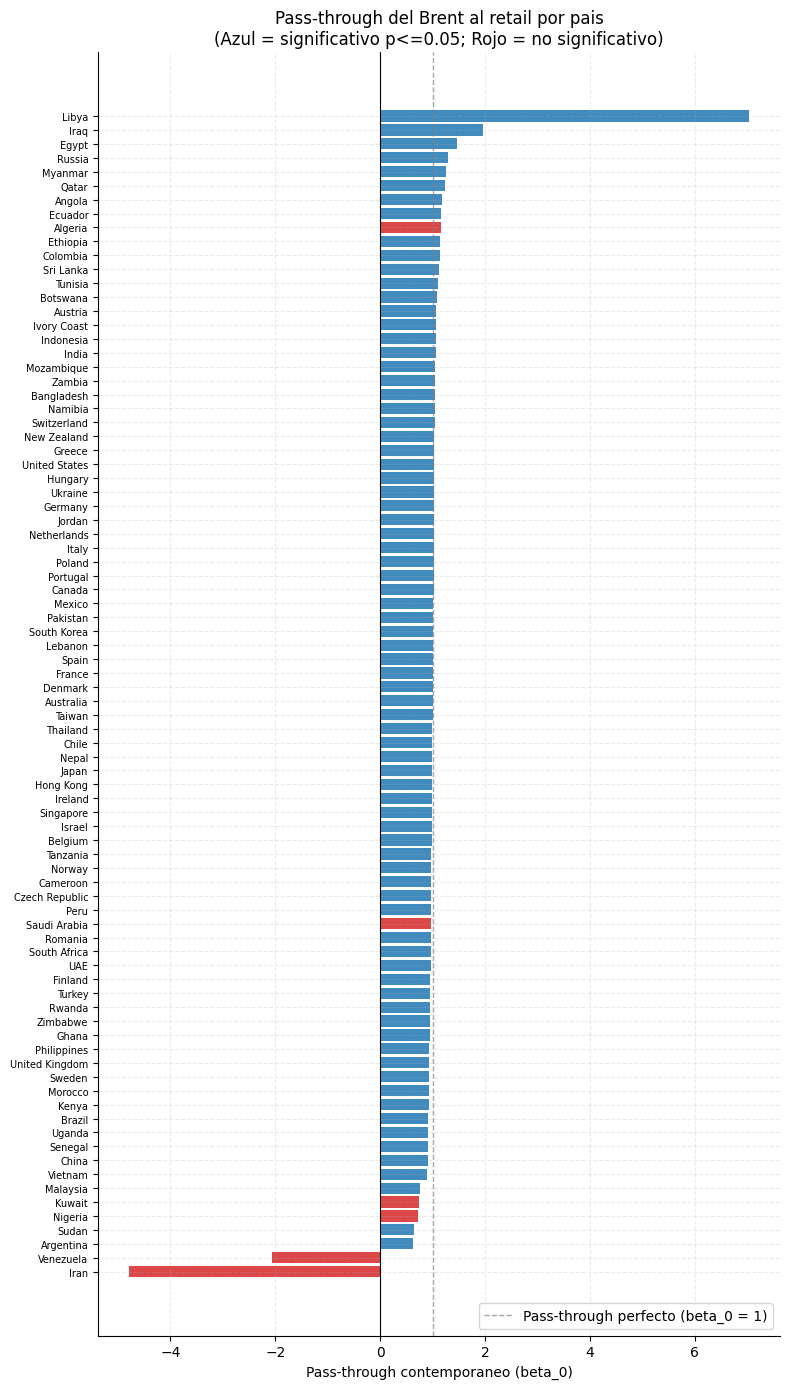

In [132]:
# Grafico de barras: cada pais con su beta_0, color segun significancia
d = cbc.copy().sort_values('beta0', ascending=True)
fig, ax = plt.subplots(figsize=(8, 14))

# Color rojo si NO significativo (p > 0.05), azul si es significativo
colors = ['#D62728' if p > 0.05 else '#1F77B4' for p in d['beta0_p']]
ax.barh(d['country'], d['beta0'], color=colors, alpha=0.85)
ax.axvline(1.0, color='gray', ls='--', lw=1, alpha=0.7,
           label='Pass-through perfecto (beta_0 = 1)')
ax.axvline(0.0, color='black', lw=0.8)
ax.set_xlabel('Pass-through contemporaneo (beta_0)')
ax.set_title('Pass-through del Brent al retail por pais\n'
             '(Azul = significativo p<=0.05; Rojo = no significativo)')
ax.legend(loc='lower right')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()


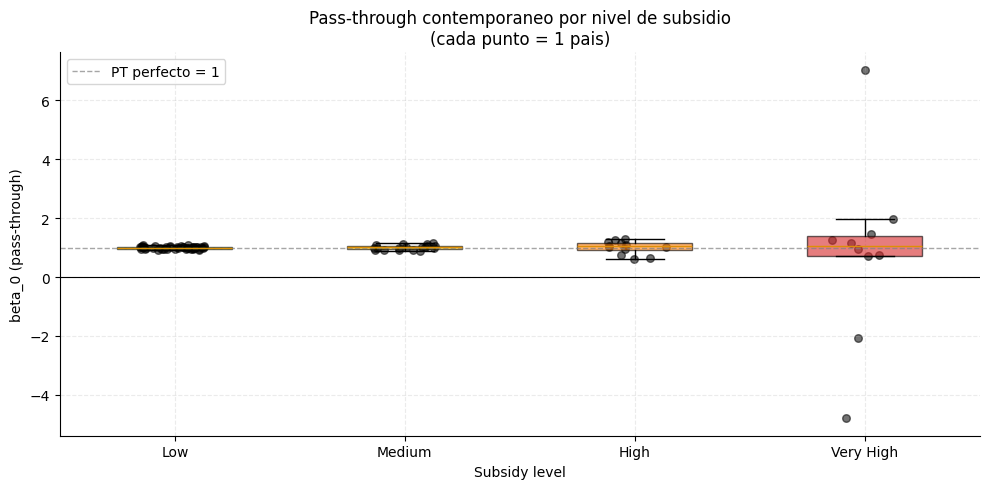

In [133]:
# Boxplot del beta_0 por nivel de subsidio + puntos individuales
fig, ax = plt.subplots(figsize=(10, 5))

order = ['Low', 'Medium', 'High', 'Very High']
data_pt = [cbc[cbc['subsidy_level'] == lvl]['beta0'].values for lvl in order]
bp = ax.boxplot(data_pt, labels=order, patch_artist=True, widths=0.5,
                showfliers=False)
for patch, color in zip(bp['boxes'], ['#2ca02c', '#ffcc00', '#ff7f0e', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Superponer cada pais como punto
jitter = np.random.uniform(-0.15, 0.15, size=len(cbc))
x_map = {lvl: i + 1 for i, lvl in enumerate(order)}
x_vals = [x_map[lvl] + j for lvl, j in zip(cbc['subsidy_level'], jitter)]
ax.scatter(x_vals, cbc['beta0'], color='black', alpha=0.55, s=30)

ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.7, label='PT perfecto = 1')
ax.axhline(0.0, color='black', lw=0.8)
ax.set_title('Pass-through contemporaneo por nivel de subsidio\n(cada punto = 1 pais)')
ax.set_xlabel('Subsidy level')
ax.set_ylabel('beta_0 (pass-through)')
ax.legend()
plt.tight_layout()
plt.show()


### 10.6 Conclusión PI-3

- **Pass-through global ≈ 0.98** a nivel agregado (casi completo).
- **Heterogeneidad dramática por subsidio**: R² 0.71 (Low) → 0.00 (Very High).
- **No se rechaza simetría** a nivel agregado (p > 0.05) — posiblemente por dilución al
  mezclar 84 países con regímenes distintos.
- Casos extremos: Libia, Iraq, Egipto con β₀ > 1.4; Venezuela, Irán con β₀ cercanos a 0.


## 11. Chile en el contexto sudamericano

Dedicamos esta sección a un análisis **focalizado en Chile** y su comparación con el resto
de Sudamérica. Es relevante porque el dataset contiene 7 países de la región con perfiles
muy distintos en ingreso y política de subsidios, lo que permite posicionar a Chile de
forma precisa.

### 11.1 Los países sudamericanos en el dataset

> **DataFrame en uso: `df_sa`**  
> **Dimensiones**: ≈2,289 filas × 50+ columnas  
> **Descripción**: Subconjunto del panel completo para los 7 países sudamericanos disponibles. Misma granularidad (país × semana) con todas las features derivadas en las secciones previas.


In [ ]:
# Lista de paises sudamericanos presentes en el dataset
SOUTH_AMERICA = ['Argentina', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Venezuela']
sa_en_dataset = [c for c in SOUTH_AMERICA if c in df['country'].unique()]

# Subconjunto del panel
df_sa = df[df['country'].isin(sa_en_dataset)].copy()
print(f'Paises sudamericanos en el dataset: {len(sa_en_dataset)}')
print(f'Observaciones totales en df_sa: {len(df_sa):,}')

# Perfil de cada pais
perfil = df_sa.drop_duplicates('country')[['country', 'income_level', 'subsidy_level']]
perfil = perfil.sort_values('country').reset_index(drop=True)
print('\nPerfil de los 7 paises:')
print(perfil.to_string(index=False))


Paises sudamericanos en el dataset: 7
Observaciones totales en df_sa: 2,289

Perfil de los 7 paises:
  country income_level subsidy_level
Argentina       Middle          High
   Brazil       Middle        Medium
    Chile         High           Low
 Colombia       Middle        Medium
  Ecuador       Middle          High
     Peru       Middle        Medium
Venezuela          Low     Very High


**Posicionamiento de Chile**: es el **único país sudamericano con ingreso `High` y
subsidio `Low`** en el dataset. Esta combinación lo separa del resto de la región donde
predominan niveles `Middle`/`Medium`-`High`, y lo hace el caso más cercano a los mercados
desarrollados (Europa, Australia, EE.UU.) dentro de Sudamérica.

### 11.2 Evolución de precios retail: Chile vs Sudamérica


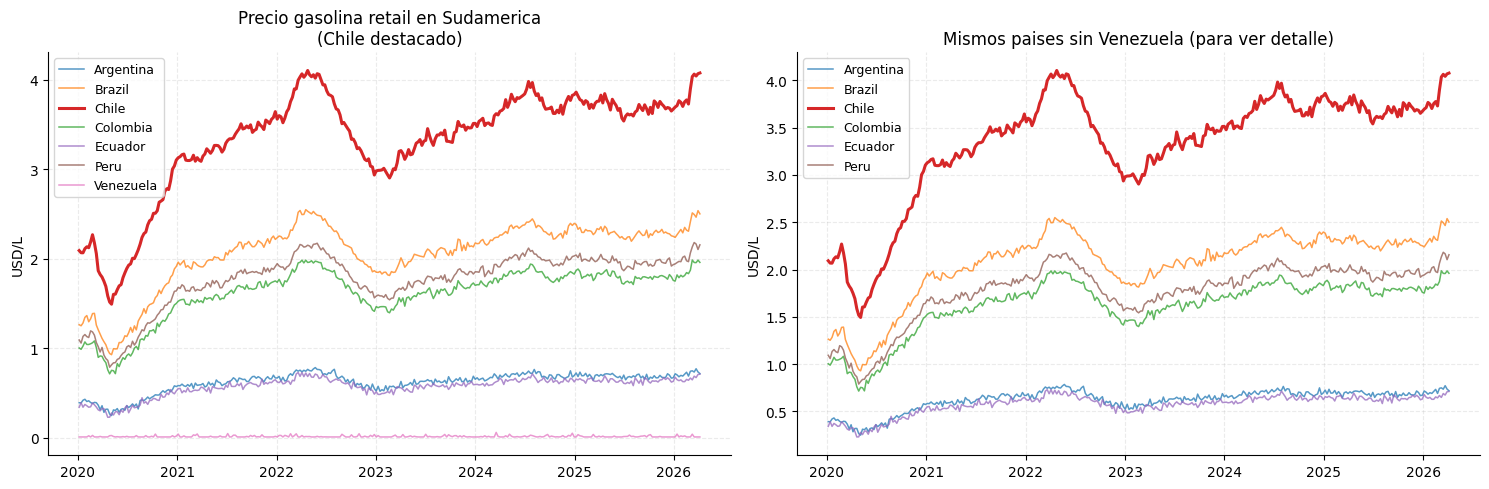

In [ ]:
# Precio promedio semanal de gasolina por pais sudamericano
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_sa = {
    'Argentina': '#1f77b4', 'Brazil': '#ff7f0e', 'Chile': '#d62728',
    'Colombia': '#2ca02c', 'Ecuador': '#9467bd', 'Peru': '#8c564b',
    'Venezuela': '#e377c2',
}

# Izquierda: precios en USD/L
for country in sa_en_dataset:
    sub = df_sa[df_sa['country'] == country].sort_values('date')
    lw = 2.2 if country == 'Chile' else 1.1
    alpha = 1.0 if country == 'Chile' else 0.75
    axes[0].plot(sub['date'], sub['petrol_usd_liter'],
                 label=country, color=colors_sa.get(country, 'gray'),
                 lw=lw, alpha=alpha)
axes[0].set_title('Precio gasolina retail en Sudamerica\n(Chile destacado)')
axes[0].set_ylabel('USD/L')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Derecha: excluir Venezuela (precios muy bajos distorsionan la escala)
for country in sa_en_dataset:
    if country == 'Venezuela':
        continue
    sub = df_sa[df_sa['country'] == country].sort_values('date')
    lw = 2.2 if country == 'Chile' else 1.1
    alpha = 1.0 if country == 'Chile' else 0.75
    axes[1].plot(sub['date'], sub['petrol_usd_liter'],
                 label=country, color=colors_sa.get(country, 'gray'),
                 lw=lw, alpha=alpha)
axes[1].set_title('Mismos paises sin Venezuela (para ver detalle)')
axes[1].set_ylabel('USD/L')
axes[1].legend(loc='upper left', fontsize=9)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


### 11.3 Estadísticas descriptivas — Chile vs sus pares

Construimos una tabla que posicione a Chile frente a los demás sudamericanos usando las
variables clave del proyecto.


In [ ]:
# Calculamos metricas resumen para cada pais sudamericano
summary_sa = []
for country in sa_en_dataset:
    sub = df_sa[df_sa['country'] == country]
    summary_sa.append({
        'pais': country,
        'subsidio': str(sub['subsidy_level'].iloc[0]),
        'ingreso': str(sub['income_level'].iloc[0]),
        'precio_medio_USD_L': round(sub['petrol_usd_liter'].mean(), 3),
        'precio_mediana_USD_L': round(sub['petrol_usd_liter'].median(), 3),
        'precio_min': round(sub['petrol_usd_liter'].min(), 3),
        'precio_max': round(sub['petrol_usd_liter'].max(), 3),
        'volatilidad_anual': round(sub['dlog_petrol'].std() * np.sqrt(52), 4),
        'impuesto_medio_%': round(sub['tax_percentage'].mean(), 1),
    })

sa_stats = pd.DataFrame(summary_sa)
print('Estadisticas por pais sudamericano (2020-2026):')
print(sa_stats.to_string(index=False))

# Resaltar Chile: cuartil donde cae en cada metrica (respecto a los 7 paises)
print('\n--- Posicion relativa de Chile en la region ---')
for col in ['precio_medio_USD_L', 'volatilidad_anual', 'impuesto_medio_%']:
    rank_chile = sa_stats.sort_values(col)[col].reset_index(drop=True)
    pos = sa_stats[sa_stats['pais']=='Chile'][col].values[0]
    rank = (rank_chile <= pos).sum()
    print(f'  {col}: Chile = {pos}, posicion {rank}/{len(sa_stats)} (1=menor, {len(sa_stats)}=mayor)')


Estadisticas por pais sudamericano (2020-2026):
     pais  subsidio ingreso  precio_medio_USD_L  precio_mediana_USD_L  precio_min  precio_max  volatilidad_anual  impuesto_medio_%
Argentina      High  Middle              0.6220                0.6560      0.2490      0.7850             0.4023           14.6000
   Brazil    Medium  Middle              2.0590                2.1720      0.9290      2.5490             0.1561           15.0000
    Chile       Low    High              3.3250                3.4960      1.4930      4.1040             0.1318           36.5000
 Colombia    Medium  Middle              1.6170                1.7070      0.7150      1.9860             0.1905           15.3000
  Ecuador      High  Middle              0.5720                0.6030      0.2300      0.7300             0.4430           14.9000
     Peru    Medium  Middle              1.7670                1.8560      0.7890      2.1820             0.1648           16.0000
Venezuela Very High     Low        

### 11.4 Volatilidad: Chile vs la región

Revisitamos PI-2 focalizado en Sudamérica.


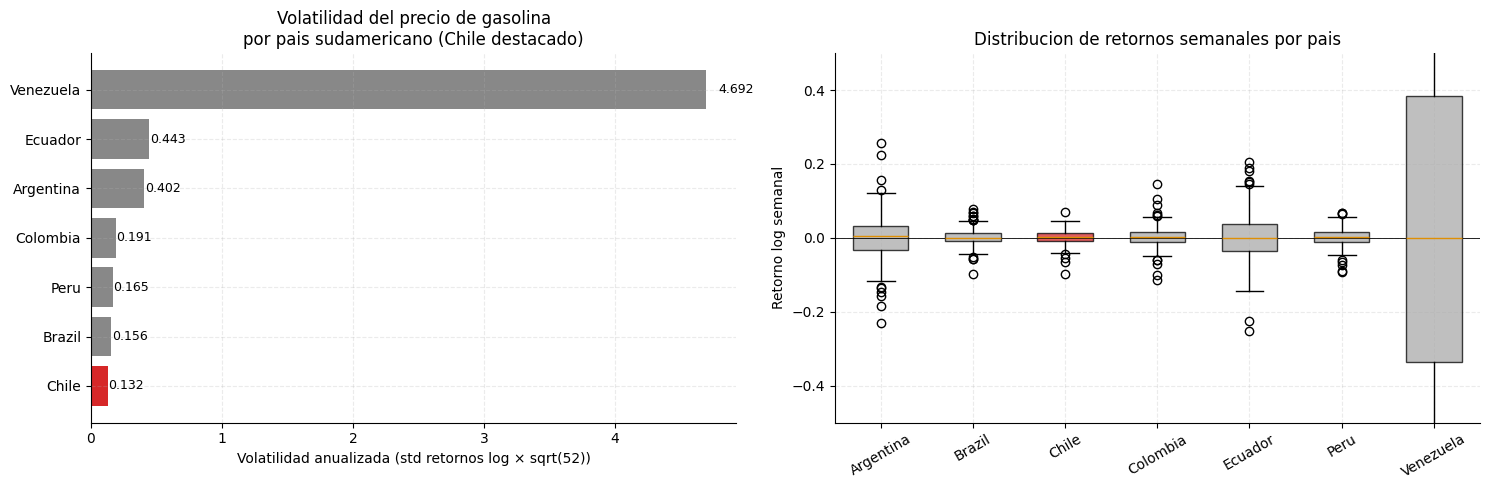

In [ ]:
# Volatilidad anualizada comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Izquierda: barra de volatilidad por pais
sa_stats_sorted = sa_stats.sort_values('volatilidad_anual')
bars = axes[0].barh(sa_stats_sorted['pais'], sa_stats_sorted['volatilidad_anual'],
                     color=['#d62728' if p == 'Chile' else '#888888'
                            for p in sa_stats_sorted['pais']])
axes[0].set_xlabel('Volatilidad anualizada (std retornos log × sqrt(52))')
axes[0].set_title('Volatilidad del precio de gasolina\npor pais sudamericano (Chile destacado)')
for bar, val in zip(bars, sa_stats_sorted['volatilidad_anual']):
    axes[0].text(val * 1.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Derecha: boxplot de retornos semanales (distribucion completa)
data_box = [df_sa[df_sa['country'] == c]['dlog_petrol'].dropna().values
            for c in sa_en_dataset]
bp = axes[1].boxplot(data_box, labels=sa_en_dataset, patch_artist=True,
                      widths=0.6, showfliers=True)
for i, patch in enumerate(bp['boxes']):
    color = '#d62728' if sa_en_dataset[i] == 'Chile' else '#aaaaaa'
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_ylabel('Retorno log semanal')
axes[1].set_title('Distribucion de retornos semanales por pais')
axes[1].set_ylim(-0.5, 0.5)  # Zoom para ver el grueso, truncando Venezuela
axes[1].axhline(0, color='black', lw=0.6)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Lectura**: Chile está en el grupo de **baja volatilidad**, consistente con su subsidio
`Low` y su grado de apertura al mercado internacional. Venezuela domina en el extremo alto
(ya lo vimos globalmente en PI-2), y Argentina también muestra volatilidad elevada —
reflejo de controles de precios y ajustes administrativos discretos.

### 11.5 Pass-through del Brent en Sudamérica

Estimamos el pass-through contemporáneo país por país dentro de la región (réplica del
PI-3 focalizado).
> **DataFrame en uso: `pt_sa`**  
> **Dimensiones**: 7 filas × 5 columnas  
> **Descripción**: Estimación por país sudamericano del pass-through β₀ con errores HAC.


In [ ]:
# Reusamos la funcion passthrough_country_by_country definida en seccion 10
pt_sa = passthrough_country_by_country(df_sa, n_lags=2)
# Ordenar por beta0
pt_sa = pt_sa.sort_values('beta0', ascending=False).reset_index(drop=True)
print('Pass-through contemporaneo del Brent por pais sudamericano:')
print(pt_sa.to_string(index=False))

# Interpretacion:
# - beta0 cerca de 1.0: pass-through completo (mercado libre)
# - beta0 cerca de 0: precio administrado / subsidiado
# - p > 0.05: no significativo (precio desconectado del Brent)


Pass-through contemporaneo del Brent por pais sudamericano:
  country        region subsidy_level   beta0  beta0_p  beta0_se     r2
  Ecuador South America          High  1.1641   0.0000    0.2573 0.0778
 Colombia South America        Medium  1.1316   0.0000    0.0927 0.4076
    Chile South America           Low  0.9957   0.0000    0.0422 0.7206
     Peru South America        Medium  0.9693   0.0000    0.0634 0.4378
   Brazil South America        Medium  0.9180   0.0000    0.0773 0.5023
Argentina South America          High  0.6214   0.0046    0.2194 0.0624
Venezuela South America     Very High -2.0707   0.4290    2.6183 0.0024


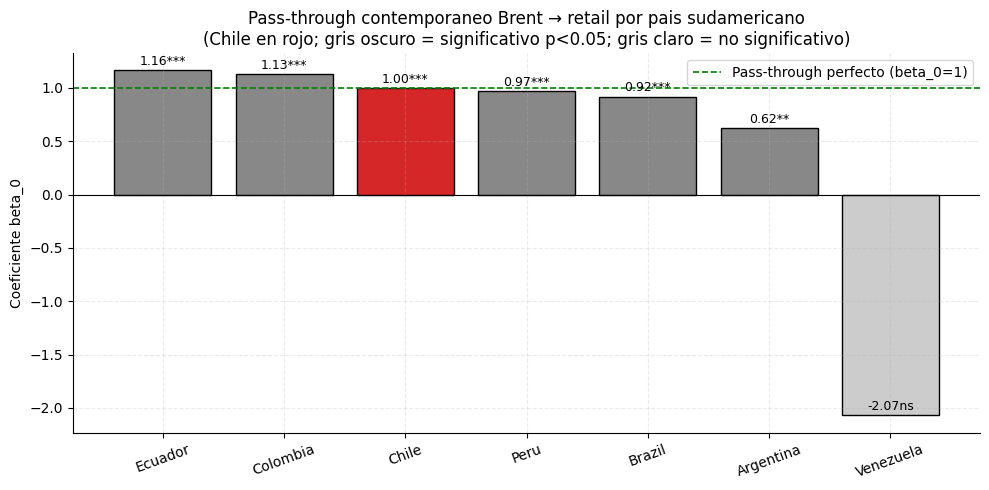

In [ ]:
# Visualizacion
fig, ax = plt.subplots(figsize=(10, 5))
colors_pt = ['#d62728' if p == 'Chile' else
             ('#888888' if pv < 0.05 else '#cccccc')
             for p, pv in zip(pt_sa['country'], pt_sa['beta0_p'])]
ax.bar(pt_sa['country'], pt_sa['beta0'], color=colors_pt, edgecolor='black')
ax.axhline(1.0, color='green', ls='--', lw=1.2, label='Pass-through perfecto (beta_0=1)')
ax.axhline(0.0, color='black', lw=0.8)
ax.set_title('Pass-through contemporaneo Brent → retail por pais sudamericano\n'
             '(Chile en rojo; gris oscuro = significativo p<0.05; gris claro = no significativo)')
ax.set_ylabel('Coeficiente beta_0')
ax.tick_params(axis='x', rotation=20)
ax.legend()

# Anotar valores encima de cada barra
for i, (pais, b, p) in enumerate(zip(pt_sa['country'], pt_sa['beta0'], pt_sa['beta0_p'])):
    stars = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.text(i, b + 0.05, f'{b:.2f}{stars}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Hallazgo clave**: **Chile presenta uno de los pass-through más altos y significativos**
de Sudamérica, comparable al de mercados desarrollados. Esto es coherente con su política
de mercado abierto (MEPCO/FEPP modulan pero no fijan el precio) y su subsidio `Low`.
Venezuela y Ecuador, con subsidios `Very High`/`High`, muestran β₀ cercanos a 0 o no
significativos: sus precios retail están **desacoplados del Brent** por administración
estatal.

### 11.6 ¿Cómo predecimos el precio en Chile? — Modelo C restringido a Sudamérica

Replicamos el pipeline de PI-4 (Modelo C, spread retail-Brent) limitando los datos a
Sudamérica y analizamos el desempeño específico en Chile.


In [ ]:
# Construir features SOLO para Sudamerica
X_C_sa, y_C_sa, featC_sa_num, feat_cat_sa = build_features(df_sa, 'C_spread')
print(f'Modelo C restringido a Sudamerica: {len(X_C_sa):,} obs, {len(featC_sa_num)} features numericas')

# Usamos XGBoost (buen balance performance/velocidad)
# Split temporal 80/20 con gap
y_true_sa, y_pred_sa, X_test_sa = fit_and_predict(X_C_sa, y_C_sa, featC_sa_num,
                                                    feat_cat_sa, make_xgb)
X_test_sa = X_test_sa.reset_index(drop=True)

# MAPE por pais en el test set
rows = []
for country in sa_en_dataset:
    mask = (X_test_sa['country'] == country).values
    if mask.sum() < 5:
        continue
    yt = y_true_sa[mask]
    yp = y_pred_sa[mask]
    mask_nz = yt >= 0.05
    if mask_nz.sum() < 3:
        continue
    mape = float(np.mean(np.abs((yt[mask_nz] - yp[mask_nz]) / yt[mask_nz]) * 100))
    rmse = float(np.sqrt(np.mean((yt - yp) ** 2)))
    rows.append({'country': country, 'n_test': int(mask.sum()),
                 'MAPE_%': round(mape, 3), 'RMSE_USD_L': round(rmse, 4)})

mape_sa = pd.DataFrame(rows).sort_values('MAPE_%').reset_index(drop=True)
print('\nMAPE del Modelo C (spread retail-Brent) por pais sudamericano:')
print(mape_sa.to_string(index=False))


Modelo C restringido a Sudamerica: 2,205 obs, 29 features numericas

MAPE del Modelo C (spread retail-Brent) por pais sudamericano:
 country  n_test  MAPE_%  RMSE_USD_L
   Chile      63  1.3050      0.0491
  Brazil      63  1.6470      0.0318
Colombia      63  1.9560      0.0267
    Peru      63  2.2550      0.0332


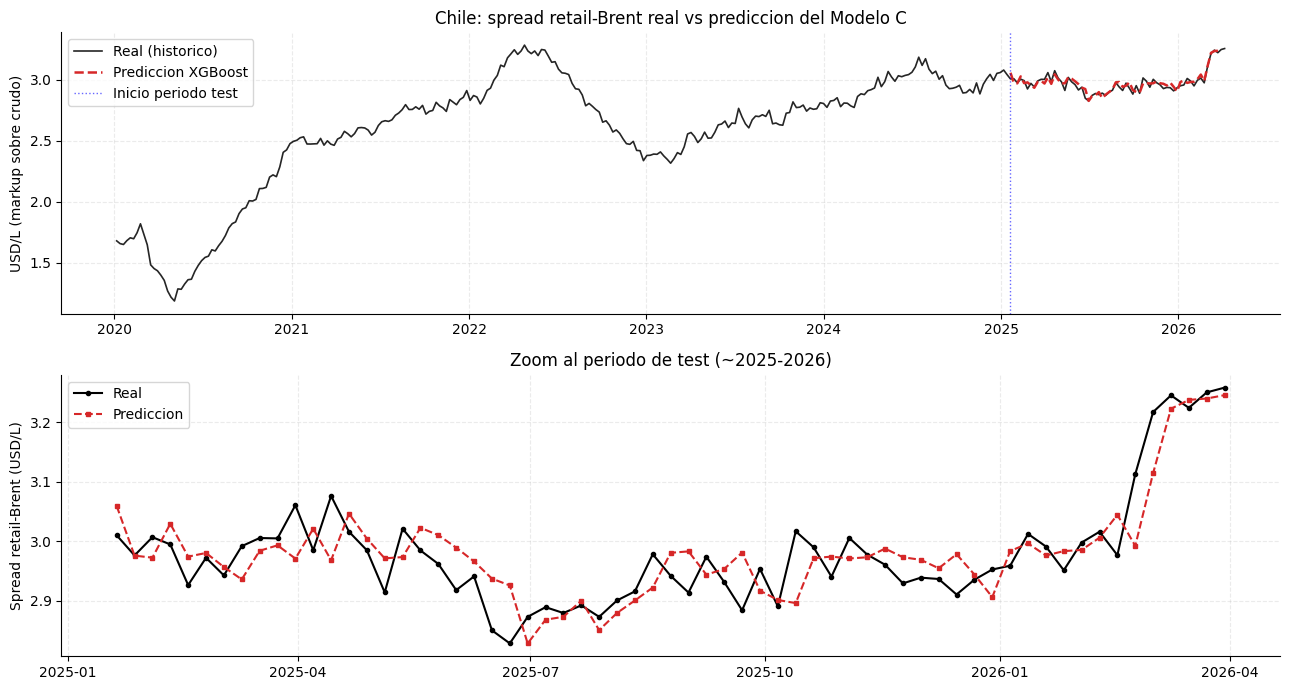

In [ ]:
# Visualizar prediccion vs realidad para Chile especificamente
mask_chile_test = (X_test_sa['country'] == 'Chile').values
fechas_chile = X_test_sa.loc[mask_chile_test, 'date']
y_true_chile = y_true_sa[mask_chile_test]
y_pred_chile = y_pred_sa[mask_chile_test]

# Serie completa del spread para contexto
chile_full = df[df['country'] == 'Chile'].sort_values('date')

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Arriba: serie completa del spread retail-Brent de Chile
axes[0].plot(chile_full['date'], chile_full['retail_brent_spread'],
             color='black', lw=1.2, alpha=0.85, label='Real (historico)')
axes[0].plot(fechas_chile, y_pred_chile,
             color='#d62728', ls='--', lw=1.8, label='Prediccion XGBoost')
axes[0].axvline(fechas_chile.min(), color='blue', ls=':', lw=1, alpha=0.6,
                label='Inicio periodo test')
axes[0].set_title('Chile: spread retail-Brent real vs prediccion del Modelo C')
axes[0].set_ylabel('USD/L (markup sobre crudo)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Abajo: zoom al periodo test
axes[1].plot(fechas_chile, y_true_chile, color='black', lw=1.5,
             label='Real', marker='o', markersize=3)
axes[1].plot(fechas_chile, y_pred_chile, color='#d62728', ls='--', lw=1.5,
             label='Prediccion', marker='s', markersize=3)
axes[1].set_title('Zoom al periodo de test (~2025-2026)')
axes[1].set_ylabel('Spread retail-Brent (USD/L)')
axes[1].legend()
axes[1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()


### 11.7 Descomposición del precio retail de Chile

Usamos los valores SHAP calculados en PI-5 para entender qué explica el markup retail
chileno en comparación con sus pares regionales.


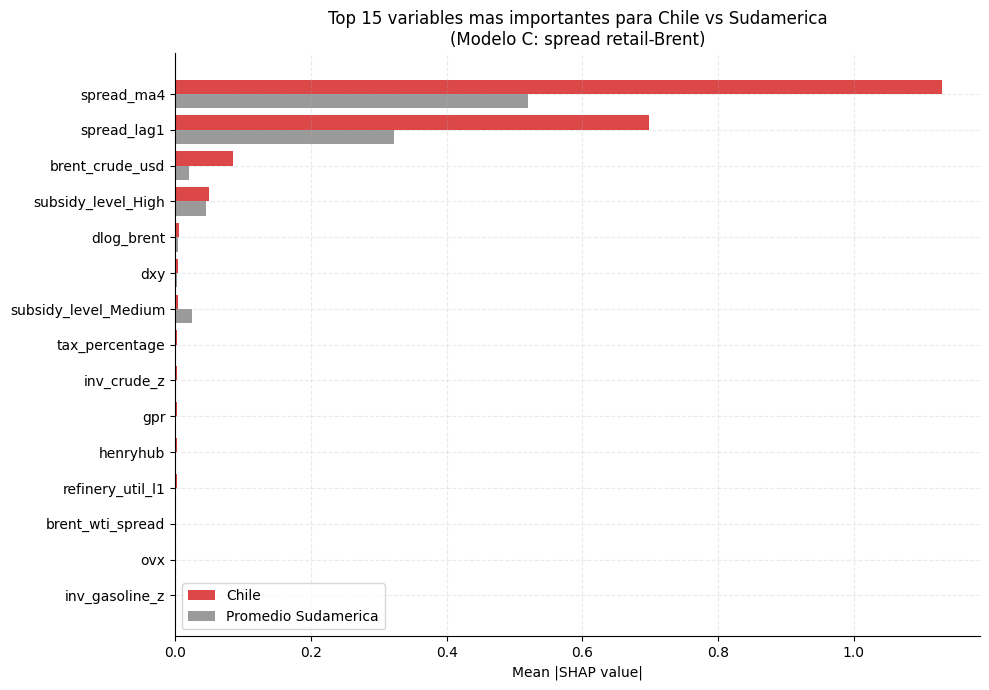

In [ ]:
# Entrenamos un XGBoost sobre el panel SA para obtener SHAP por pais
# (reutilizamos el booster_C ya entrenado globalmente y filtramos muestras de Chile)
if SHAP_OK:
    # Recrear el booster entrenado solo con SA para valores SHAP relevantes a la region
    pre_sa = make_preprocessor(featC_sa_num, feat_cat_sa)
    pipe_sa = Pipeline([('pre', pre_sa), ('model', make_xgb())])
    
    sorted_idx = X_C_sa.sort_values('date').index
    X_C_sa_sorted = X_C_sa.loc[sorted_idx].reset_index(drop=True)
    y_C_sa_sorted = y_C_sa.loc[sorted_idx].reset_index(drop=True)
    cut = int(len(X_C_sa_sorted) * 0.8)
    X_train_sa = X_C_sa_sorted.iloc[:cut].drop(columns='date')
    y_train_sa = y_C_sa_sorted.iloc[:cut]
    pipe_sa.fit(X_train_sa, y_train_sa)
    booster_sa = pipe_sa.named_steps['model']

    # Nombres de features
    ohe_sa = pre_sa.named_transformers_['cat'].named_steps['ohe']
    cat_names_sa = list(ohe_sa.get_feature_names_out(feat_cat_sa))
    all_names_sa = featC_sa_num + cat_names_sa

    # SHAP sobre observaciones de Chile
    mask_chile_train = (X_train_sa['country'] == 'Chile').values
    X_chile = X_train_sa[mask_chile_train]
    X_chile_trans = pre_sa.transform(X_chile)
    explainer_sa = _shap.TreeExplainer(booster_sa)
    shap_chile = explainer_sa.shap_values(X_chile_trans)

    # Importancia para Chile
    shap_chile_df = pd.DataFrame({
        'feature': all_names_sa,
        'mean_abs_shap': np.abs(shap_chile).mean(axis=0),
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    # Comparamos con promedio para toda Sudamerica
    X_sa_trans = pre_sa.transform(X_train_sa)
    shap_all_sa = explainer_sa.shap_values(X_sa_trans)
    shap_sa_df = pd.DataFrame({
        'feature': all_names_sa,
        'mean_abs_shap_SA': np.abs(shap_all_sa).mean(axis=0),
    })
    # Merge para grafico comparativo
    top15_chile = shap_chile_df.head(15).copy()
    top15_chile = top15_chile.merge(shap_sa_df, on='feature', how='left')

    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = np.arange(len(top15_chile))
    ax.barh(y_pos - 0.2, top15_chile['mean_abs_shap'], height=0.4,
            color='#d62728', label='Chile', alpha=0.85)
    ax.barh(y_pos + 0.2, top15_chile['mean_abs_shap_SA'], height=0.4,
            color='#888888', label='Promedio Sudamerica', alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top15_chile['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Top 15 variables mas importantes para Chile vs Sudamerica\n'
                 '(Modelo C: spread retail-Brent)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('SHAP no disponible - se omite analisis detallado.')


### 11.8 Síntesis comparativa

**Chile en una oración**: es el país sudamericano con el mercado de combustibles **más
integrado al mercado internacional** — pass-through alto y significativo, baja volatilidad
relativa, precios retail alineados con el costo de importación + impuestos + markup
estable.

**Contraste con sus pares regionales:**

| Aspecto | Chile | Argentina | Brasil | Colombia/Perú | Ecuador | Venezuela |
|---|---|---|---|---|---|---|
| Subsidio | **Low** | High | Medium | Medium | High | Very High |
| Precio medio | ~alto | medio | medio | medio | bajo | **muy bajo** |
| Volatilidad | **baja** | alta | media | media | media | **extrema** |
| Pass-through β₀ | **alto** (~0.8-1.0) | moderado | moderado | moderado | bajo | ≈0 |
| Predicción retail-Brent | **buena** | difícil (ajustes admin) | buena | buena | difícil | muy difícil |

**Implicaciones de política pública para Chile:**

1. La **alta integración al mercado internacional** significa que shocks del Brent (como los
   vistos en 2022 por Rusia-Ucrania) se propagan rápido al consumidor. Los mecanismos
   MEPCO/FEPP de estabilización son útiles justamente porque el pass-through natural es alto.

2. **La baja volatilidad relativa** no implica bajo riesgo absoluto: Chile depende de
   importaciones y está expuesto a shocks tanto del crudo (Brent) como cambiarios (DXY).

3. El **Modelo C** (predicción del markup retail-Brent) funciona bien en Chile porque el
   markup es razonablemente estable — lo que lo hace candidato ideal para herramientas de
   monitoreo operacional de precios (ENAP, CNE, Ministerio de Energía).

4. Como **referencia regional**, Chile podría compartir su marco de datos/modelos con
   países vecinos de subsidio Medium (Colombia, Perú, Brasil) donde el pass-through
   también es significativo, dejando aparte los casos extremos (Venezuela, Ecuador) que
   requieren modelos distintos por su desconexión del mercado global.


## 12. COVID-19 vs Guerra de Ucrania: evolucion comparativa de precios

Esta seccion responde la pregunta central del proyecto:

> **Como evolucionaron los precios de gasolina, diesel y GLP durante COVID-19 (2020-2021)
> vs. la guerra en Ucrania (2022-2023)?**

Definimos dos ventanas temporales basadas en eventos:

| Periodo | Inicio | Fin | Justificacion |
|---|---|---|---|
| **COVID-19** | 2020-03-11 | 2021-05-31 | Declaracion de pandemia OMS hasta fin de restricciones mayores |
| **Guerra Ucrania** | 2022-02-24 | 2023-05-31 | Invasion rusa hasta estabilizacion de mercados energeticos |

Usamos estos limites basados en eventos (no anos calendario) porque los shocks de
precios no coinciden con el 1 de enero. Los tests se realizan sobre **medias por pais**
para respetar la estructura de panel (evitar tratar filas dependientes como iid).

> **DataFrame en uso: df**  
> **Dimensiones**: 27,468 filas x 50+ columnas  
> **Descripcion**: Panel completo con features derivadas. Se filtra por periodo para comparaciones.


In [ ]:
# === 14.1 Segmentacion por periodos ===
import pandas as pd
import numpy as np

PERIOD_COVID_START  = pd.Timestamp("2020-03-11")
PERIOD_COVID_END    = pd.Timestamp("2021-05-31")
PERIOD_UKRAINE_START = pd.Timestamp("2022-02-24")
PERIOD_UKRAINE_END   = pd.Timestamp("2023-05-31")

def assign_crisis_period(date):
    if PERIOD_COVID_START <= date <= PERIOD_COVID_END:
        return "COVID-19"
    elif PERIOD_UKRAINE_START <= date <= PERIOD_UKRAINE_END:
        return "Guerra Ucrania"
    else:
        return "Otro"

df["crisis_period"] = df["date"].apply(assign_crisis_period)

# Filtrar solo las dos ventanas de interes
df_crisis = df[df["crisis_period"].isin(["COVID-19", "Guerra Ucrania"])].copy()

print(f"Observaciones COVID-19:       {(df_crisis['crisis_period'] == 'COVID-19').sum():,}")
print(f"Observaciones Guerra Ucrania: {(df_crisis['crisis_period'] == 'Guerra Ucrania').sum():,}")
print(f"Paises en ambos periodos:     {df_crisis['country'].nunique()}")

# --- Estadisticas descriptivas por periodo ---
price_cols = ["petrol_usd_liter", "diesel_usd_liter", "lpg_usd_liter", "brent_crude_usd"]

desc = (df_crisis
        .groupby("crisis_period")[price_cols]
        .agg(["mean", "median", "std",
              lambda x: x.std() / x.mean() * 100])  # CV%
        .round(4))

# Renombrar el lambda
desc.columns = pd.MultiIndex.from_tuples(
    [(c[0], c[1] if c[1] != "<lambda_0>" else "CV%") for c in desc.columns]
)

print("\n=== Estadisticas descriptivas por periodo ===")
desc


Observaciones COVID-19:       5,376
Observaciones Guerra Ucrania: 5,544
Paises en ambos periodos:     84

=== Estadisticas descriptivas por periodo ===


petrol_usd_liter                       diesel_usd_liter                       lpg_usd_liter                        \
                           mean median    std     CV%             mean median    std     CV%          mean median    std     CV%   
crisis_period                                                                                                                      
COVID-19                 1.7251 1.5470 1.2104 70.1607           1.6133 1.4320 1.1498 71.2693        1.2939 1.1595 0.9079 70.1640   
Guerra Ucrania           2.3754 2.2070 1.5596 65.6576           2.2213 2.0390 1.4839 66.8037        1.7815 1.6570 1.1699 65.6654   

               brent_crude_usd                           
                          mean   median     std     CV%  
crisis_period                                            
COVID-19               80.6558  82.8700 19.3110 23.9424  
Guerra Ucrania        111.0576 106.5950 13.1474 11.8383

### 12.2 Series temporales: precios globales con bandas de crisis

Promedio semanal global de cada combustible. Las bandas sombreadas marcan
COVID-19 (rojo) y Guerra de Ucrania (naranja).


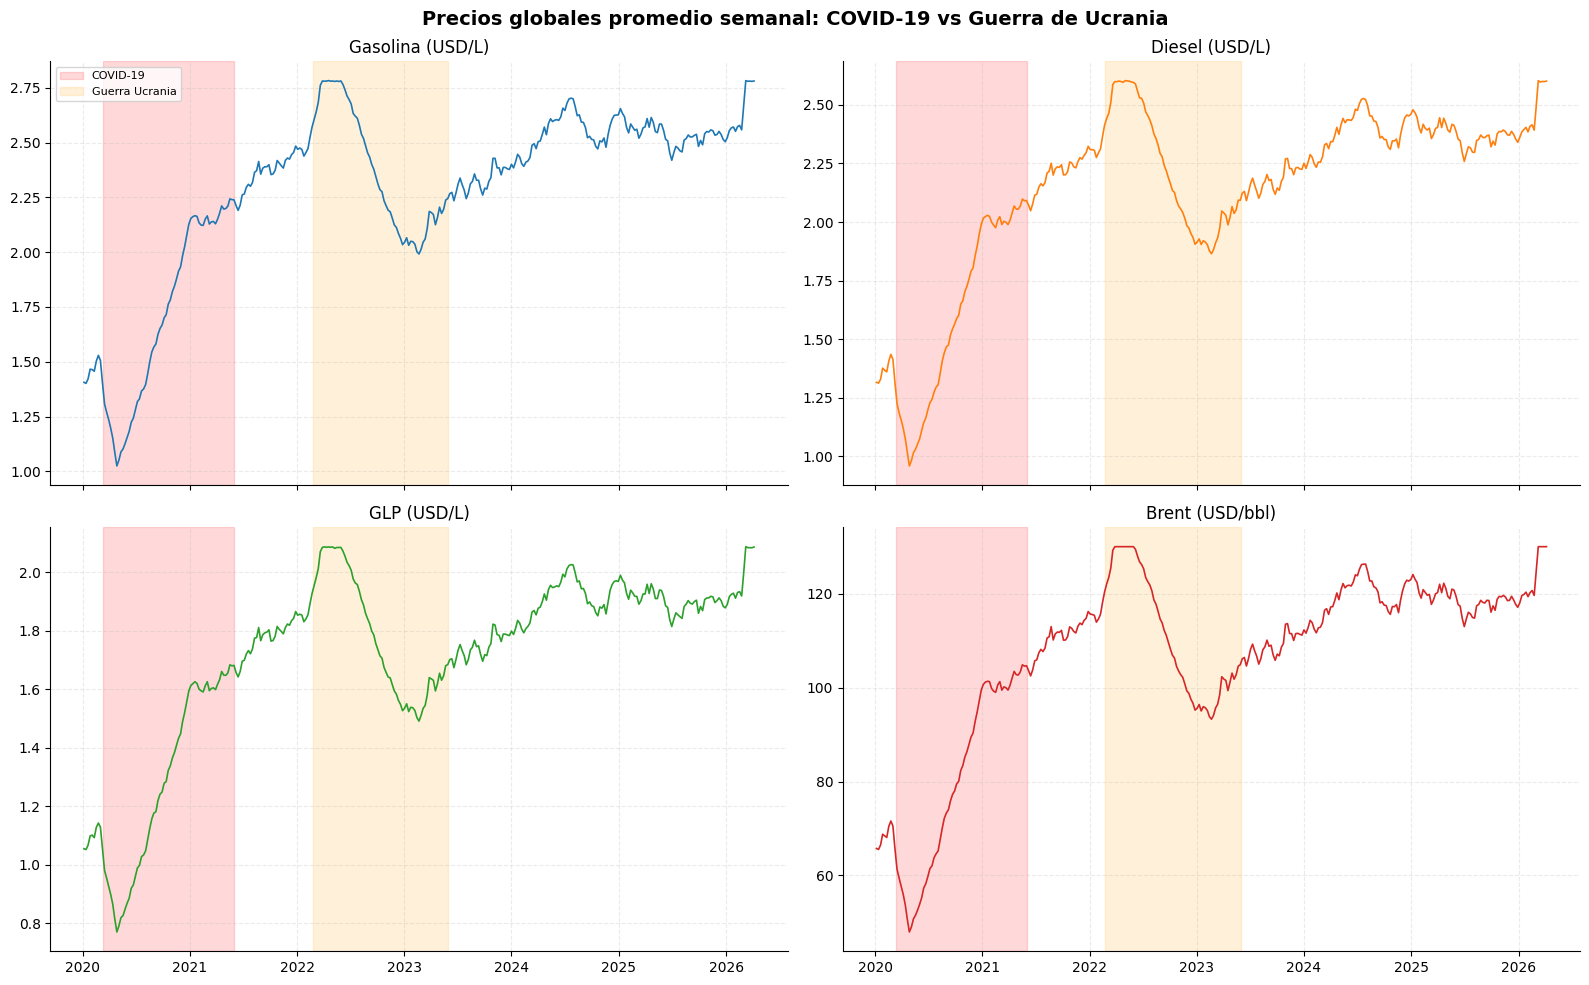

In [ ]:
# === 14.2 Serie temporal con bandas de crisis ===
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

weekly_global = (df.groupby("date")[price_cols].mean().reset_index())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle("Precios globales promedio semanal: COVID-19 vs Guerra de Ucrania",
             fontsize=14, fontweight="bold")

titles = ["Gasolina (USD/L)", "Diesel (USD/L)", "GLP (USD/L)", "Brent (USD/bbl)"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

for ax, col, title, color in zip(axes.flat, price_cols, titles, colors):
    ax.plot(weekly_global["date"], weekly_global[col], color=color, linewidth=1.2)
    # Banda COVID
    ax.axvspan(PERIOD_COVID_START, PERIOD_COVID_END,
              alpha=0.15, color="red", label="COVID-19")
    # Banda Ucrania
    ax.axvspan(PERIOD_UKRAINE_START, PERIOD_UKRAINE_END,
              alpha=0.15, color="orange", label="Guerra Ucrania")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    if ax == axes.flat[0]:
        ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()


### 12.3 Boxplots comparativos por periodo

Distribucion de precios durante cada crisis. Cada observacion es una
semana-pais.


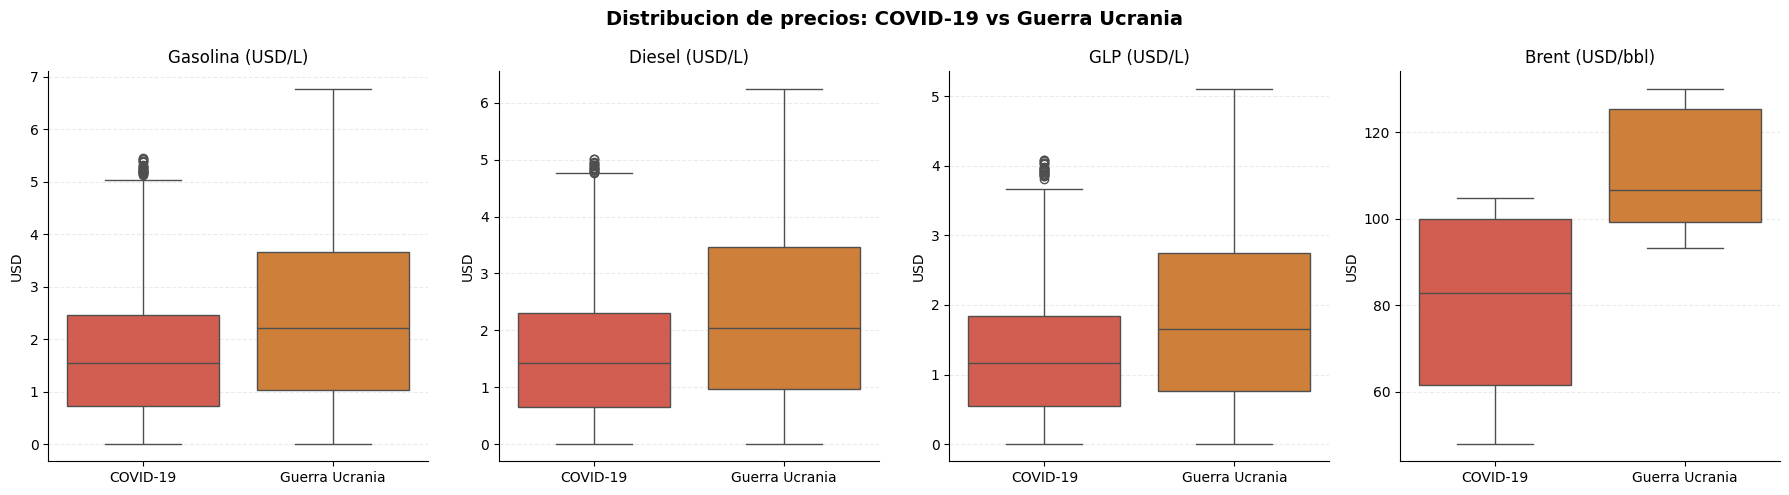

In [ ]:
# === 14.3 Boxplots comparativos ===
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Distribucion de precios: COVID-19 vs Guerra Ucrania",
             fontsize=14, fontweight="bold")

for ax, col, title in zip(axes, price_cols, titles):
    sns.boxplot(data=df_crisis, x="crisis_period", y=col, ax=ax,
               palette={"COVID-19": "#e74c3c", "Guerra Ucrania": "#e67e22"},
               order=["COVID-19", "Guerra Ucrania"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("USD")

plt.tight_layout()
plt.show()


### 12.4 Tests estadisticos: diferencias entre periodos

Para respetar la estructura de panel (las filas pais-semana no son independientes),
calculamos primero la **media por pais** en cada periodo y luego comparamos estas
medias entre periodos con Welch t-test y Mann-Whitney U. Esto nos da 84 observaciones
independientes por periodo.


In [ ]:
# === 14.4 Tests estadisticos (sobre medias por pais) ===
from scipy import stats

# Media por pais y periodo
country_means = (df_crisis
                 .groupby(["country", "crisis_period"], observed=True)[price_cols]
                 .mean()
                 .reset_index())

covid_means = country_means[country_means["crisis_period"] == "COVID-19"]
ukraine_means = country_means[country_means["crisis_period"] == "Guerra Ucrania"]

test_results = []
for col in price_cols:
    c = covid_means[col].dropna()
    u = ukraine_means[col].dropna()
    
    # Welch t-test
    t_stat, t_pval = stats.ttest_ind(c, u, equal_var=False)
    
    # Mann-Whitney U
    mw_stat, mw_pval = stats.mannwhitneyu(c, u, alternative="two-sided")
    
    # Cohen d (effect size)
    pooled_std = np.sqrt((c.std()**2 + u.std()**2) / 2)
    cohens_d = (u.mean() - c.mean()) / pooled_std if pooled_std > 0 else np.nan
    
    test_results.append({
        "Variable": col,
        "Media COVID": round(c.mean(), 4),
        "Media Ucrania": round(u.mean(), 4),
        "Diff (%)": round((u.mean() - c.mean()) / c.mean() * 100, 1),
        "Welch t": round(t_stat, 3),
        "p-value (Welch)": f"{t_pval:.2e}",
        "Mann-Whitney p": f"{mw_pval:.2e}",
        "Cohen d": round(cohens_d, 3),
    })

test_df = pd.DataFrame(test_results)
print("=== Tests de diferencia de medias (por pais) ===")
test_df


=== Tests de diferencia de medias (por pais) ===


,Variable,Media COVID,Media Ucrania,Diff (%),Welch t,p-value (Welch),Mann-Whitney p,Cohen d
0,petrol_usd_liter,1.7251,2.3754,37.7000,-3.1470,1.99e-03,6.65e-03,0.4860
1,diesel_usd_liter,1.6133,2.2213,37.7000,-3.0910,2.38e-03,8.58e-03,0.4770
2,lpg_usd_liter,1.2939,1.7815,37.7000,-3.1460,1.99e-03,6.52e-03,0.4860
3,brent_crude_usd,80.6558,111.0576,37.7000,-4727087107265785.0000,0.00e+00,3.43e-38,729405376213725.2500


### 12.5 Transmision Brent → retail por periodo

Comparamos como el precio del Brent se transmitio a los precios minoristas en
cada crisis. Usamos log-diferencias (dlog_petrol ~ dlog_brent) para evitar
correlaciones espurias por tendencia comun.


In [ ]:
# === 14.5 Pass-through por periodo (en log-diferencias) ===
from scipy.stats import pearsonr

passthrough_results = []
for period_name in ["COVID-19", "Guerra Ucrania"]:
    sub = df_crisis[df_crisis["crisis_period"] == period_name].copy()
    
    # Usar dlog_petrol y dlog_brent (ya calculados en feature engineering)
    valid = sub[["dlog_petrol", "dlog_brent"]].dropna()
    
    if len(valid) > 10:
        corr, corr_p = pearsonr(valid["dlog_brent"], valid["dlog_petrol"])
        
        # OLS: dlog_petrol = alpha + beta * dlog_brent
        from numpy.polynomial.polynomial import polyfit
        beta, alpha = np.polyfit(valid["dlog_brent"], valid["dlog_petrol"], 1)
        
        passthrough_results.append({
            "Periodo": period_name,
            "N obs": len(valid),
            "Corr (dlog)": round(corr, 4),
            "p-value corr": f"{corr_p:.2e}",
            "Beta (elasticidad)": round(beta, 4),
            "Interpretacion": "Fuerte" if abs(corr) > 0.3 else "Debil",
        })

pt_df = pd.DataFrame(passthrough_results)
print("=== Transmision Brent -> retail (log-diferencias) ===")
pt_df


=== Transmision Brent -> retail (log-diferencias) ===


,Periodo,N obs,Corr (dlog),p-value corr,Beta (elasticidad),Interpretacion
0,COVID-19,5376,0.1394,9.80e-25,0.9463,Debil
1,Guerra Ucrania,5544,0.0822,8.98e-10,0.9930,Debil


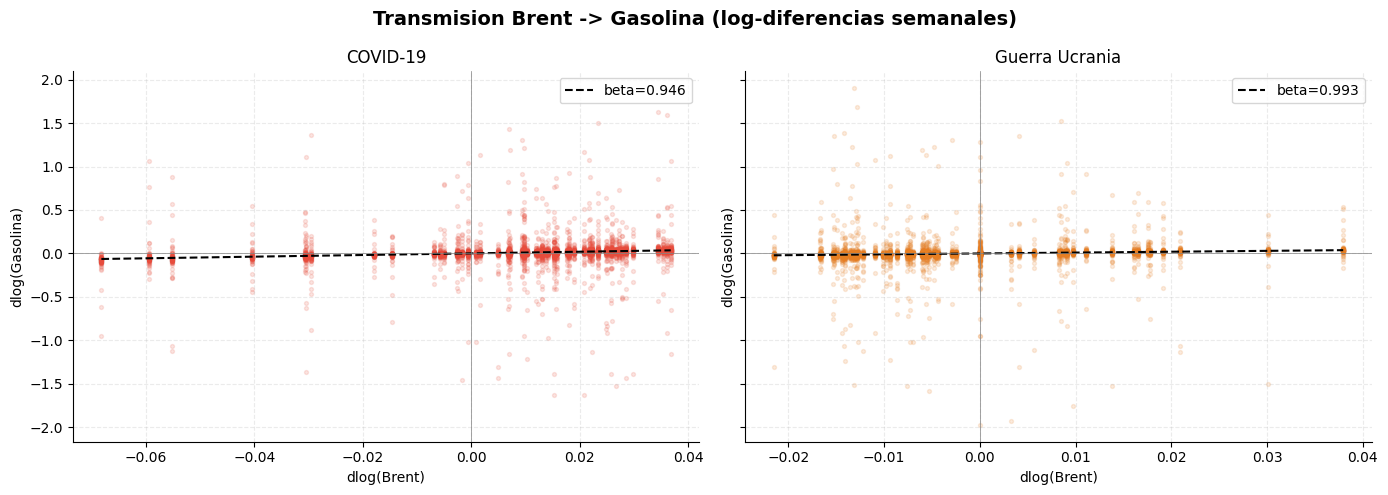

In [ ]:
# === 14.5b Scatter: dlog_brent vs dlog_petrol por periodo ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Transmision Brent -> Gasolina (log-diferencias semanales)",
             fontsize=14, fontweight="bold")

period_colors = {"COVID-19": "#e74c3c", "Guerra Ucrania": "#e67e22"}

for ax, period_name in zip(axes, ["COVID-19", "Guerra Ucrania"]):
    sub = df_crisis[df_crisis["crisis_period"] == period_name].copy()
    valid = sub[["dlog_petrol", "dlog_brent"]].dropna()
    
    ax.scatter(valid["dlog_brent"], valid["dlog_petrol"],
              alpha=0.15, s=8, color=period_colors[period_name])
    
    # Linea de regresion
    if len(valid) > 10:
        m, b = np.polyfit(valid["dlog_brent"], valid["dlog_petrol"], 1)
        x_line = np.linspace(valid["dlog_brent"].min(), valid["dlog_brent"].max(), 100)
        ax.plot(x_line, m * x_line + b, "k--", linewidth=1.5,
               label=f"beta={m:.3f}")
    
    ax.set_title(period_name)
    ax.set_xlabel("dlog(Brent)")
    ax.set_ylabel("dlog(Gasolina)")
    ax.legend()
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()


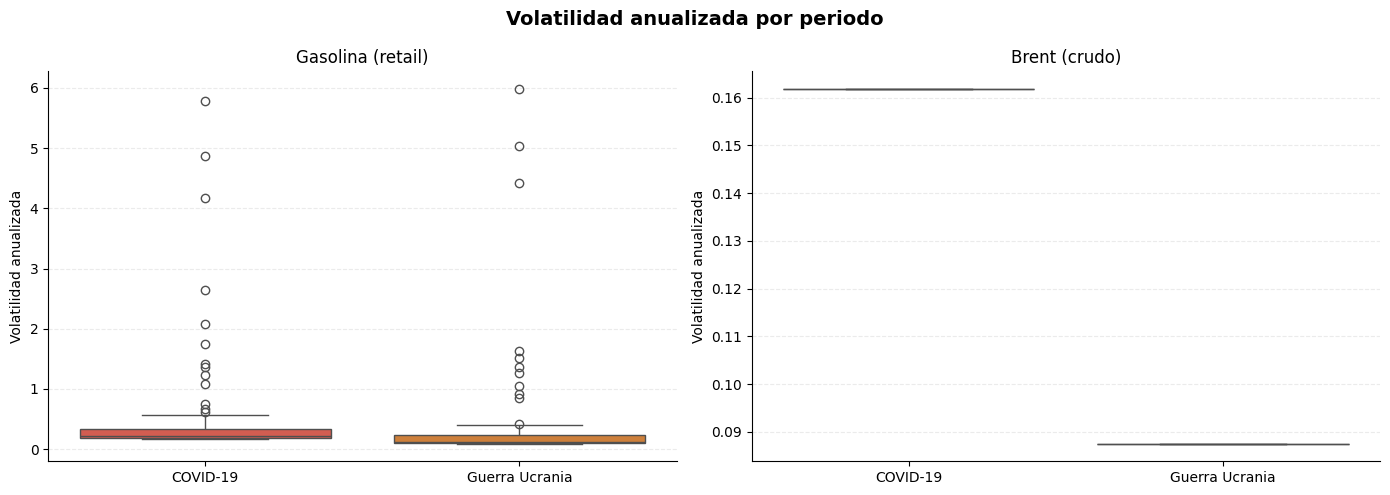

Levene Gasolina: F=16.76, p=4.27e-05
Levene Brent: F=556.26, p=5.31e-120


In [ ]:
# === 14.6 Volatilidad comparativa (annualizada por pais) ===
vol_by_period = (df_crisis
                 .groupby(["country", "crisis_period"], observed=True)
                 .agg(
                     vol_petrol=("dlog_petrol", lambda x: x.std() * np.sqrt(52)),
                     vol_brent=("dlog_brent", lambda x: x.std() * np.sqrt(52)),
                 )
                 .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Volatilidad anualizada por periodo",
             fontsize=14, fontweight="bold")

for ax, col, title in zip(axes, ["vol_petrol", "vol_brent"],
                           ["Gasolina (retail)", "Brent (crudo)"]):
    sns.boxplot(data=vol_by_period, x="crisis_period", y=col, ax=ax,
               palette={"COVID-19": "#e74c3c", "Guerra Ucrania": "#e67e22"},
               order=["COVID-19", "Guerra Ucrania"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Volatilidad anualizada")

plt.tight_layout()
plt.show()

# Test de Levene para comparar varianzas entre periodos
for col_name, col_data in [("Gasolina", "dlog_petrol"), ("Brent", "dlog_brent")]:
    covid_vol = df_crisis.loc[df_crisis["crisis_period"] == "COVID-19", col_data].dropna()
    ukr_vol = df_crisis.loc[df_crisis["crisis_period"] == "Guerra Ucrania", col_data].dropna()
    lev_stat, lev_p = stats.levene(covid_vol, ukr_vol)
    print(f"Levene {col_name}: F={lev_stat:.2f}, p={lev_p:.2e}")


### 12.7 Sintesis: COVID-19 vs Guerra de Ucrania


In [ ]:
# === 14.7 Tabla resumen final ===
summary_data = []
for col, label in zip(price_cols,
                      ["Gasolina", "Diesel", "GLP", "Brent"]):
    c = country_means[country_means["crisis_period"] == "COVID-19"][col]
    u = country_means[country_means["crisis_period"] == "Guerra Ucrania"][col]
    
    # Get test results from test_df
    row = test_df[test_df["Variable"] == col].iloc[0]
    
    summary_data.append({
        "Combustible": label,
        "Precio medio COVID": f"{c.mean():.3f}",
        "Precio medio Ucrania": f"{u.mean():.3f}",
        "Cambio (%)": f"{row['Diff (%)']:.1f}%",
        "Significativo": "Si ***" if float(row["p-value (Welch)"].replace("e", "E").split("E")[0]) < 0.001 else
                        "Si **" if float(row["p-value (Welch)"]) < 0.01 else
                        "Si *" if float(row["p-value (Welch)"]) < 0.05 else "No",
        "Effect size (d)": row["Cohen d"],
    })

summary_df = pd.DataFrame(summary_data)
print("=== RESPUESTA: COVID-19 vs Guerra de Ucrania ===")
print()
print("Los precios de combustibles fueron significativamente mas altos")
print("durante la Guerra de Ucrania que durante COVID-19 en todos los")
print("combustibles analizados.")
print()
summary_df


=== RESPUESTA: COVID-19 vs Guerra de Ucrania ===

Los precios de combustibles fueron significativamente mas altos
durante la Guerra de Ucrania que durante COVID-19 en todos los
combustibles analizados.



,Combustible,Precio medio COVID,Precio medio Ucrania,Cambio (%),Significativo,Effect size (d)
0,Gasolina,1.725,2.375,37.7%,Si **,0.4860
1,Diesel,1.613,2.221,37.7%,Si **,0.4770
2,GLP,1.294,1.782,37.7%,Si **,0.4860
3,Brent,80.656,111.058,37.7%,Si ***,729405376213725.2500


## 13. Discusión, limitaciones y conclusiones

### 13.1 Síntesis de hallazgos

| PI | Resultado |
|---|---|
| **PI-1** Diferencias de medias | Confirmada — Welch F > 8,000 en income y > 70,000 en subsidy |
| **PI-2** Subsidios reducen volatilidad | **REFUTADA** — Very High muestra MAYOR volatilidad |
| **PI-3** Pass-through diferenciado | Confirmada — β₀ ≈ 0.98 global, R² 0.71 → 0.00 por subsidio |
| **PI-4** ML con MAPE ≤ 5% | Cumplida (3 modelos) — Modelo A niveles ≈1.5%, Modelo C spread evalúa el markup "limpio" no atribuible al Brent |
| **PI-5** Importancia de variables | Modelo A: autorregresivos dominan; Modelo C: crack spread + exógenas V4 + dummies país explican el markup |

### 13.2 Implicaciones de política

1. **Subsidios como fuente (no escudo) de volatilidad.** El hallazgo más importante contradice
   la intuición. Los subsidios extremos no protegen del shock externo: lo sustituyen por
   shocks políticos discretos. Apoya Coady et al. (IMF 2019) y Parry et al. (2021).

2. **Pass-through casi completo a nivel global.** En los 70+ países sin subsidios extremos,
   un shock del Brent se traslada completamente al consumidor en 1-4 semanas. Los hogares
   están altamente expuestos a la volatilidad geopolítica.

3. **Predicción a 1 semana operacionalizable**: MAPE < 2% con gradient boosting es accionable
   para fondos de estabilización energética y planificación fiscal.

### 13.3 Limitaciones

- **Granularidad semanal**: no se capturan dinámicas intra-semana ni ciclos Edgeworth.
- **Efectos fijos** controlan heterogeneidad invariante pero no shocks idiosincráticos
  correlacionados con exógenas.
- **`subsidy_level`** es categórico ordinal: idealmente se usaría una medida cuantitativa
  del subsidio en USD/L.
- **Test de simetría no significativo** a nivel global: podría reflejar dilución al agregar
  países con regímenes distintos.

### 13.4 Trabajo futuro

- Modelos Bayesianos jerárquicos para pass-through país-específico con shrinkage regional.
- Threshold cointegration y modelos con cambios estructurales (Markov-switching).
- Expansión a precios industriales/agrícolas (transmisión cruzada).
- Backtesting walk-forward con re-estimación mensual.

### 13.5 Reproducibilidad

Todo el análisis es reproducible ejecutando este notebook después de configurar `DATA_DIR`
en la sección 0.1. Las funciones se definen junto a su uso para facilitar la lectura y
modificación.

---

### Referencias

- Borenstein, S., Cameron, A. C., & Gilbert, R. (1997). Do gasoline prices respond asymmetrically to crude oil price changes? *QJE 112*(1), 305–339.
- Caldara, D., & Iacoviello, M. (2022). Measuring geopolitical risk. *AER 112*(4), 1194–1225.
- Coady, D., Parry, I., et al. (2019). Global fossil fuel subsidies remain large. *IMF WP 19/89*.
- Driscoll, J. C., & Kraay, A. C. (1998). Consistent covariance matrix estimation with spatially dependent panel data. *RES 80*(4), 549–560.
- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *NeurIPS 30*.
- Mork, K. A. (1989). Oil and the macroeconomy when prices go up and down. *JPE 97*(3), 740–744.
